# Auditory Naming — Behavioral Analysis

Patients: **AA· AZ· DR· LH· RB· WBH**

| Section | Topic |
|---------|-------|
| 1 | Response validity & overall naming accuracy per patient |
| 2 | Per-word / per-prompt accuracy (consistently easy vs hard words) |
| 3 | Wrong-but-close answers — semantic similarity between target and answered word |
| 4 | Reaction time (go-cue → voice onset; do patients ignore the go cue?) |
| 5 | Stimulus characteristics (duration, word count) |
| 6 | Embedding comparison: target word Â· answered word Â· prompt sentence |

---
## 0. Imports & setup

In [35]:
import os, sys, warnings, collections
import numpy as np
import pandas as pd
import dill
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    from nltk.stem import WordNetLemmatizer
    _lemmatizer = WordNetLemmatizer()
except Exception:
    _lemmatizer = None


# ---- loose-accuracy helpers ----
import nltk
try:
    from nltk.corpus import wordnet as wn
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4',  quiet=True)
    _ARTICLES = ('a ', 'an ', 'the ')
    def _normalize(w):
        s = str(w).strip().lower()
        for art in _ARTICLES:
            if s.startswith(art):
                s = s[len(art):]; break
        base = ''.join(c for c in s if c.isalpha())
        return _lemmatizer.lemmatize(base, pos='n')
    def _share_synset(w1, w2):
        s1 = set(wn.synsets(w1, pos=wn.NOUN))
        s2 = set(wn.synsets(w2, pos=wn.NOUN))
        return bool(s1 & s2)
    def _correct_loose(target, answered, valid):
        if not valid: return False
        tn, an = _normalize(target), _normalize(answered)
        return tn == an or _share_synset(tn, an)
except Exception:
    def _normalize(w):
        s = str(w).strip().lower()
        for art in ('a ', 'an ', 'the '):
            if s.startswith(art):
                s = s[len(art):]; break
        return ''.join(c for c in s if c.isalpha())
    def _correct_loose(target, answered, valid):
        if not valid: return False
        return _normalize(target) == _normalize(answered)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# Work from main/ regardless of launch directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

print('CWD:', os.getcwd())

CWD: d:\OneDrive - Northwestern University\PycharmProjects\Speech\main


## 1. Configuration

In [36]:
DATA_ROOT = 'data'
PATIENTS  = ['AA', 'AZ', 'DR', 'LH', 'RB', 'WBH']
TASK      = 'auditory_naming'

# Tokens that mean the patient gave no usable answer
_INVALID = frozenset({
    '', 'nan', 'none', 'n/a', 'na', '?', 'x',
    'pass', 'skip', 'no response', 'nr', 'error',
})

def is_valid(w):
    s = str(w).strip().lower()
    return s not in _INVALID and any(c.isalpha() for c in s)

# One colour per patient
PAL = dict(zip(PATIENTS, sns.color_palette('tab10', len(PATIENTS))))

print('Patients:', PATIENTS)
print('Palette:', {k: tuple(round(x, 2) for x in v) for k, v in PAL.items()})

Patients: ['AA', 'AZ', 'DR', 'LH', 'RB', 'WBH']
Palette: {'AA': (0.12, 0.47, 0.71), 'AZ': (1.0, 0.5, 0.05), 'DR': (0.17, 0.63, 0.17), 'LH': (0.84, 0.15, 0.16), 'RB': (0.58, 0.4, 0.74), 'WBH': (0.55, 0.34, 0.29)}


## 2. Load raw data

In [37]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return dill.load(f)

raw_dfs    = {}  # patient → DataFrame
raw_labels = {}  # patient → labels DataFrame (may be absent)

for pt in PATIENTS:
    folder = os.path.join(DATA_ROOT, pt)

    # ---- df pkl ----
    df_path = None
    for suffix in [f'{pt}_{TASK}_df.pkl', f'{pt}_{TASK}_combined_df.pkl']:
        p = os.path.join(folder, suffix)
        if os.path.exists(p):
            df_path = p
            break

    if df_path is None:
        print(f'[SKIP] {pt}: no df pkl found in {folder}')
        continue

    df = load_pkl(df_path)
    if isinstance(df, dict):
        df = pd.DataFrame(df)
    raw_dfs[pt] = df
    print(f'{pt}: {len(df):3d} trials  cols={list(df.columns)}')

    # ---- labels pkl ----
    lbl_path = os.path.join(folder, f'{pt}_{TASK}_labels.pkl')
    if os.path.exists(lbl_path):
        lbl = load_pkl(lbl_path)
        if isinstance(lbl, dict):
            lbl = pd.DataFrame(lbl)
        raw_labels[pt] = lbl
    else:
        print(f'       {pt}: no labels pkl — categories will be "unknown"')

AA:  53 trials  cols=['session', 'hg_data', 'trial_onset', 'go_cue_onset', 'trial_offset', 'voice_onset', 'voice_offset', 'target_word', 'answered_word', 'bad_channels', 'bad_trials', 'fs', 'channel_names', 'fixation_onset', 'prompt_type', 'prompt_words', 'prompt_word_onsets', 'prompt_word_offsets']
AZ: 104 trials  cols=['session', 'hg_data', 'trial_onset', 'go_cue_onset', 'trial_offset', 'voice_onset', 'voice_offset', 'target_word', 'answered_word', 'bad_channels', 'bad_trials', 'fs', 'channel_names', 'fixation_onset', 'prompt_type', 'prompt_words', 'prompt_word_onsets', 'prompt_word_offsets']
DR:  51 trials  cols=['session', 'hg_data', 'trial_onset', 'go_cue_onset', 'trial_offset', 'voice_onset', 'voice_offset', 'target_word', 'answered_word', 'bad_channels', 'bad_trials', 'fs', 'channel_names', 'fixation_onset', 'prompt_type', 'prompt_words', 'prompt_word_onsets', 'prompt_word_offsets']
LH: 176 trials  cols=['session', 'hg_data', 'trial_onset', 'go_cue_onset', 'trial_offset', 'voice

## 3. Build combined behavioral DataFrame

In [38]:
def _arr(row, col):
    """Safely extract a numpy array from a DataFrame row."""
    v = row.get(col, None)
    if v is None:
        return np.array([np.nan])
    return np.asarray(v, dtype=float).ravel()

if '_correct_loose' not in globals():
    raise RuntimeError("Run Cell 3 (Imports & setup) before this cell so _correct_loose is defined.")

records = []

for pt, df in raw_dfs.items():
    lbl   = raw_labels.get(pt)
    w2cat = {}
    if lbl is not None and 'target_word' in lbl.columns:
        cat_col = next((c for c in ('class', 'category', 'label') if c in lbl.columns), None)
        if cat_col:
            w2cat = dict(zip(
                lbl['target_word'].astype(str).str.strip().str.lower(),
                lbl[cat_col].astype(str)
            ))

    for i, row in df.iterrows():
        target   = str(row.get('target_word',   '')).strip()
        answered = str(row.get('answered_word', '')).strip()

        # ---- Stimulus timing ----
        onsets  = _arr(row, 'prompt_word_onsets')
        offsets = _arr(row, 'prompt_word_offsets')
        stim_onset  = float(onsets[0])   if len(onsets)  > 0 else np.nan
        stim_offset = float(offsets[-1]) if len(offsets) > 0 else np.nan
        stim_dur    = (
            stim_offset - stim_onset
            if np.isfinite(stim_onset) and np.isfinite(stim_offset) else np.nan
        )
        n_words_prompt = int(len(onsets))

        pw = row.get('prompt_words', None)
        prompt_sentence = (
            ' '.join(np.asarray(pw).ravel().astype(str))
            if pw is not None else ''
        )

        # ---- Key timepoints ----
        go_cue    = float(row.get('go_cue_onset',  np.nan))
        voice_on  = float(row.get('voice_onset',   np.nan))
        voice_off = float(row.get('voice_offset',  np.nan))
        trial_on  = float(row.get('trial_onset',   np.nan))

        rt_from_go       = voice_on - go_cue    if np.isfinite(go_cue)    and np.isfinite(voice_on)  else np.nan
        rt_from_stim_end = voice_on - stim_offset if np.isfinite(stim_offset) and np.isfinite(voice_on) else np.nan
        gap_stim_to_go   = go_cue - stim_offset  if np.isfinite(stim_offset) and np.isfinite(go_cue)   else np.nan

        # ---- Accuracy ----
        valid = is_valid(answered)
        correct_verbatim = (target.lower() == answered.lower()) if valid else False
        correct_loose    = _correct_loose(target, answered, valid)

        category  = w2cat.get(target.lower(), 'unknown')
        is_good   = bool(row.get('bad_trials', True))

        records.append(dict(
            patient          = pt,
            trial_idx        = i,
            target           = target,
            answered         = answered,
            valid_response   = valid,
            correct_verbatim = correct_verbatim,
            correct_loose    = correct_loose,
            category         = category,
            stim_onset       = stim_onset,
            stim_offset      = stim_offset,
            stim_dur         = stim_dur,
            n_words_prompt   = n_words_prompt,
            prompt_sentence  = prompt_sentence,
            go_cue           = go_cue,
            voice_onset      = voice_on,
            voice_offset     = voice_off,
            trial_onset      = trial_on,
            rt_from_go       = rt_from_go,
            rt_from_stim_end = rt_from_stim_end,
            gap_stim_to_go   = gap_stim_to_go,
            is_good_trial    = is_good,
        ))

beh   = pd.DataFrame(records)
beh_v = beh[beh['valid_response']].copy()   # valid attempted answers only

print(f'Total trials:        {len(beh)}')
print(f'Valid responses:     {len(beh_v)} ({100*len(beh_v)/max(1,len(beh)):.1f}%)')
print(f'Good trial flag:     {beh["is_good_trial"].sum()}')
print()
print(beh.groupby('patient')[['correct_verbatim','correct_loose']]
        .mean().round(3))

Total trials:        834
Valid responses:     834 (100.0%)
Good trial flag:     834

         correct_verbatim  correct_loose
patient                                 
AA                  0.868          0.906
AZ                  0.798          0.923
DR                  0.667          0.745
LH                  0.858          0.909
RB                  0.276          0.757
WBH                 0.695          0.922


---
## Section 1 — Overall naming accuracy per patient

patient  n_trials  n_valid  n_correct_v  n_correct_loose  pct_valid  acc_verbatim  acc_loose
     AA        53       53           46               48      100.0          86.8       90.6
     AZ       104      104           83               96      100.0          79.8       92.3
     DR        51       51           34               38      100.0          66.7       74.5
     LH       176      176          151              160      100.0          85.8       90.9
     RB       181      181           50              137      100.0          27.6       75.7
    WBH       269      269          187              248      100.0          69.5       92.2


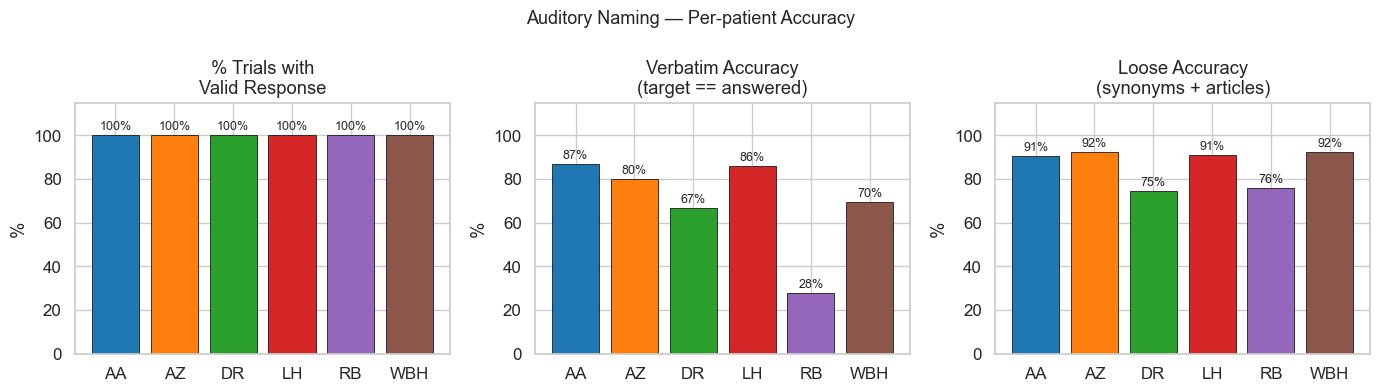

In [39]:
summary = beh.groupby('patient').agg(
    n_trials       = ('trial_idx',         'count'),
    n_valid        = ('valid_response',    'sum'),
    n_correct_v    = ('correct_verbatim',  'sum'),
    n_correct_loose = ('correct_loose',    'sum'),
).reset_index()
summary['pct_valid']    = 100 * summary['n_valid'] / summary['n_trials']
summary['acc_verbatim'] = 100 * summary['n_correct_v'] / summary['n_valid'].replace(0, np.nan)
summary['acc_loose']    = 100 * summary['n_correct_loose'] / summary['n_valid'].replace(0, np.nan)

print(summary.round(1).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ['pct_valid', 'acc_verbatim', 'acc_loose'],
    ['% Trials with\nValid Response',
     'Verbatim Accuracy\n(target == answered)',
     'Loose Accuracy\n(synonyms + articles)'],
):
    colors = [PAL[p] for p in summary['patient']]
    bars = ax.bar(summary['patient'], summary[col], color=colors,
                  edgecolor='k', linewidth=0.6)
    ax.set_ylim(0, 115)
    ax.set_ylabel('%')
    ax.set_title(title)
    for bar, val in zip(bars, summary[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Auditory Naming — Per-patient Accuracy', fontsize=13)
plt.tight_layout()
plt.show()

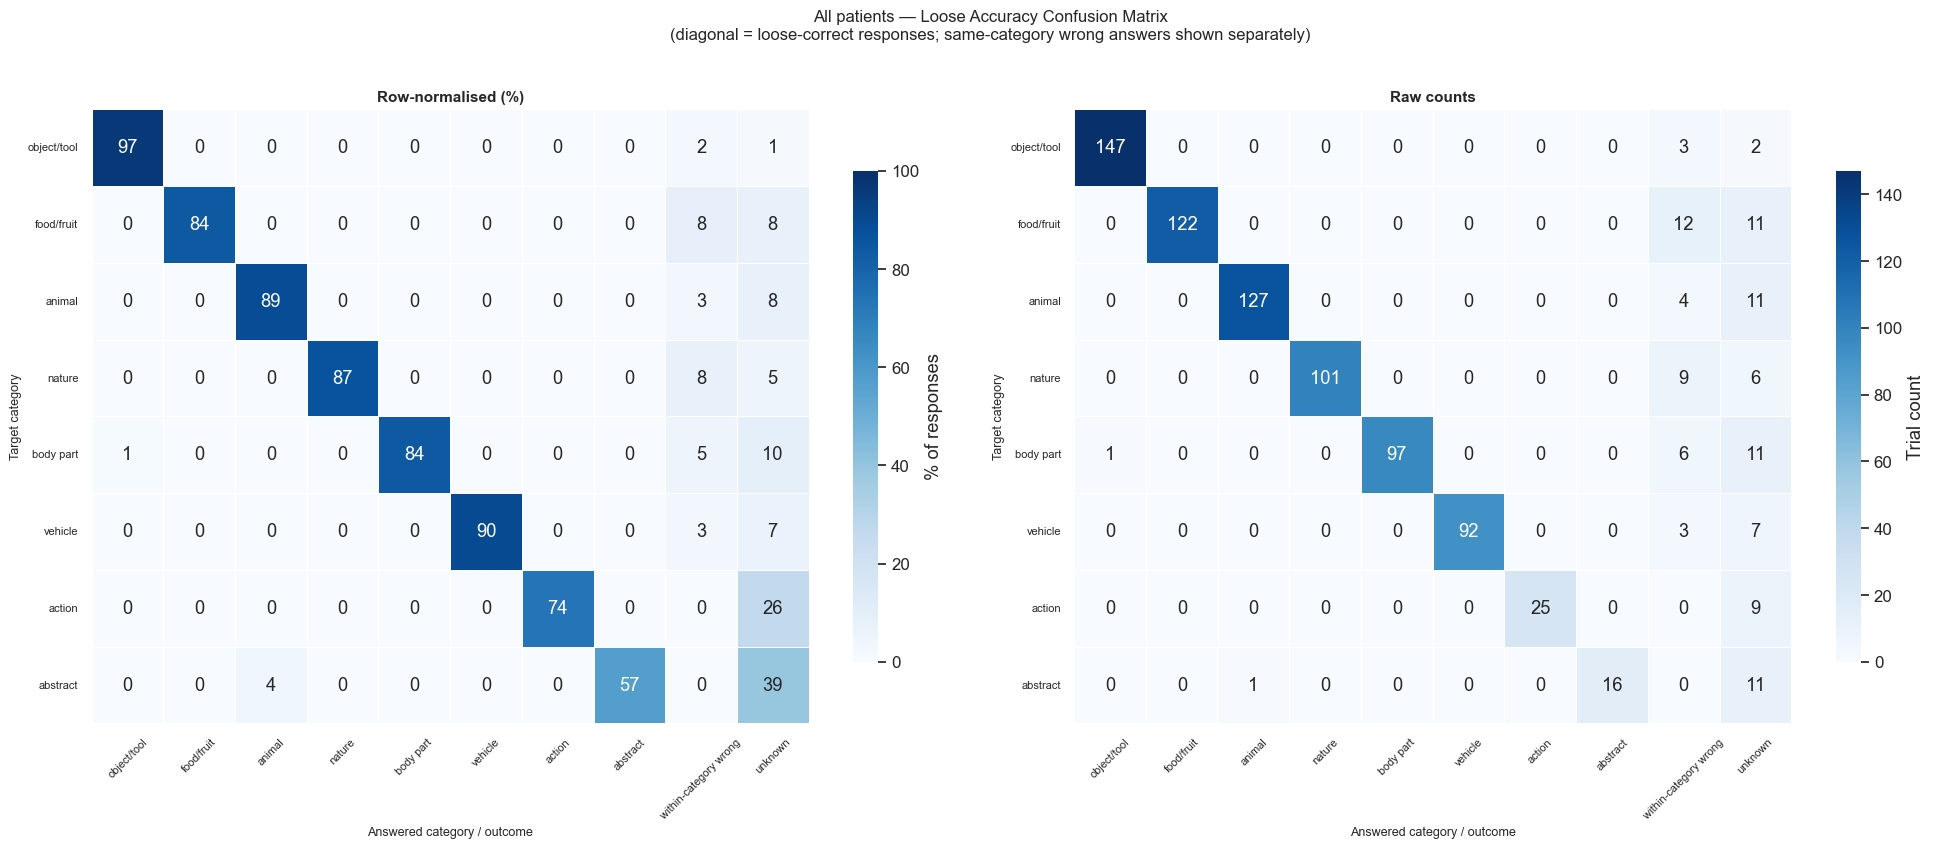

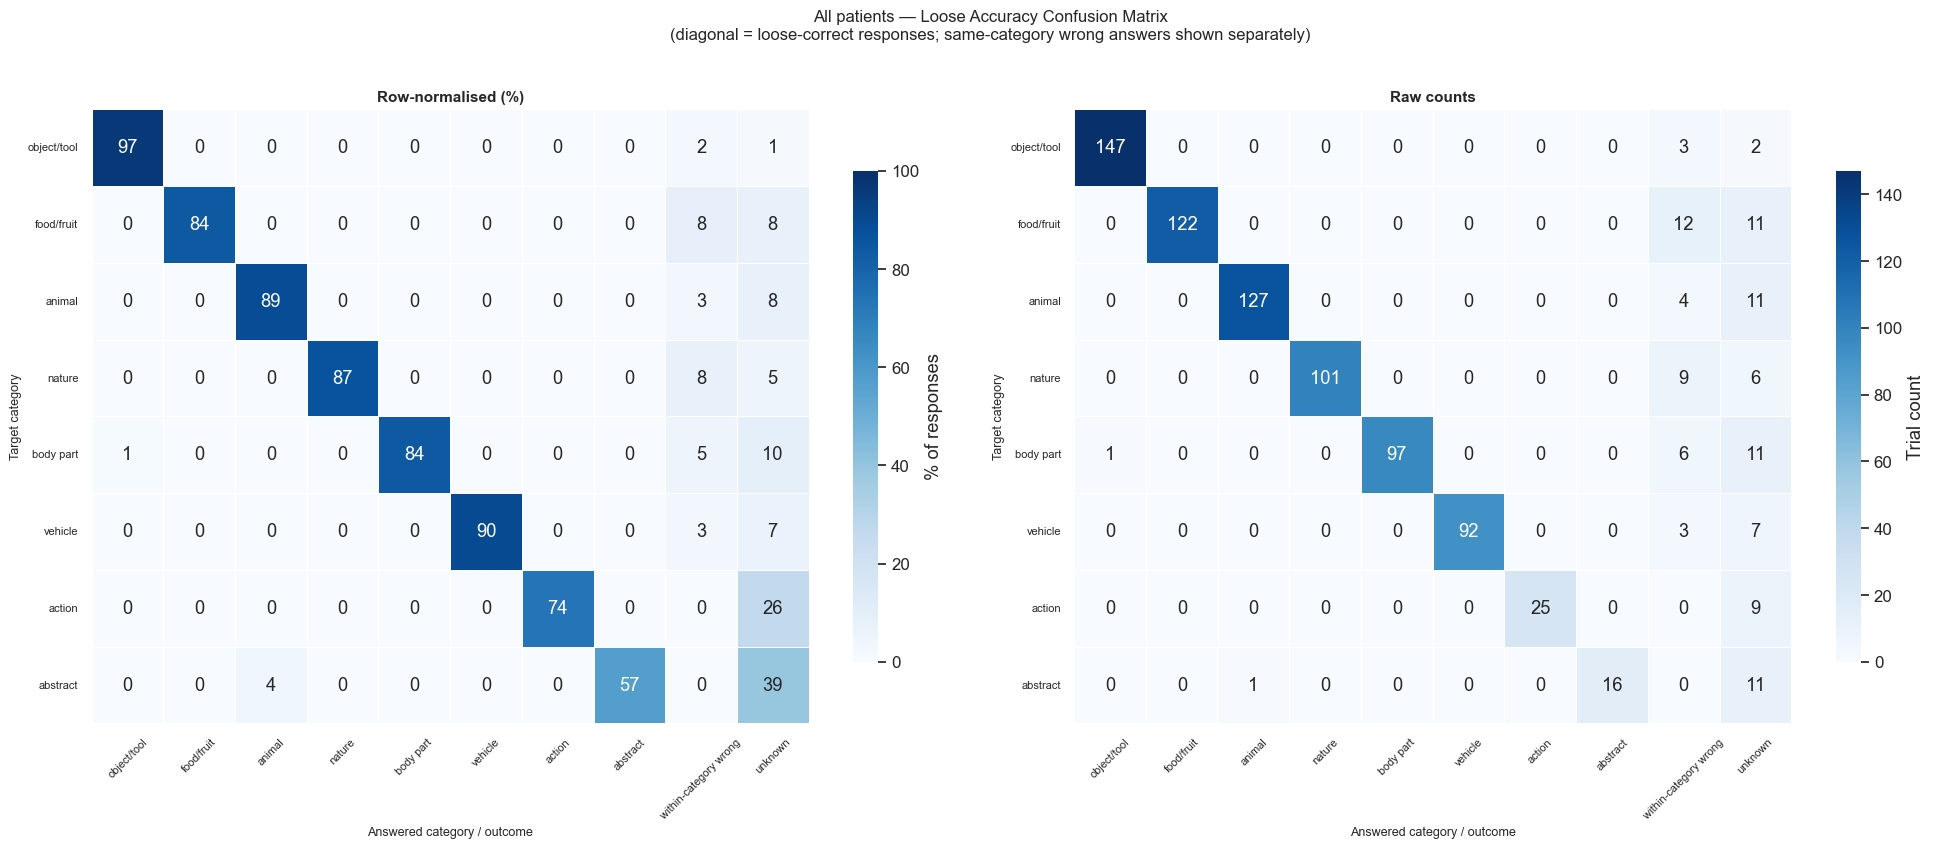

Diagonal accuracy per category (all patients):
             loose_acc_%  n_correct  n_total
object/tool         96.7        147      152
food/fruit          84.1        122      145
animal              89.4        127      142
nature              87.1        101      116
body part           84.3         97      115
vehicle             90.2         92      102
action              73.5         25       34
abstract            57.1         16       28


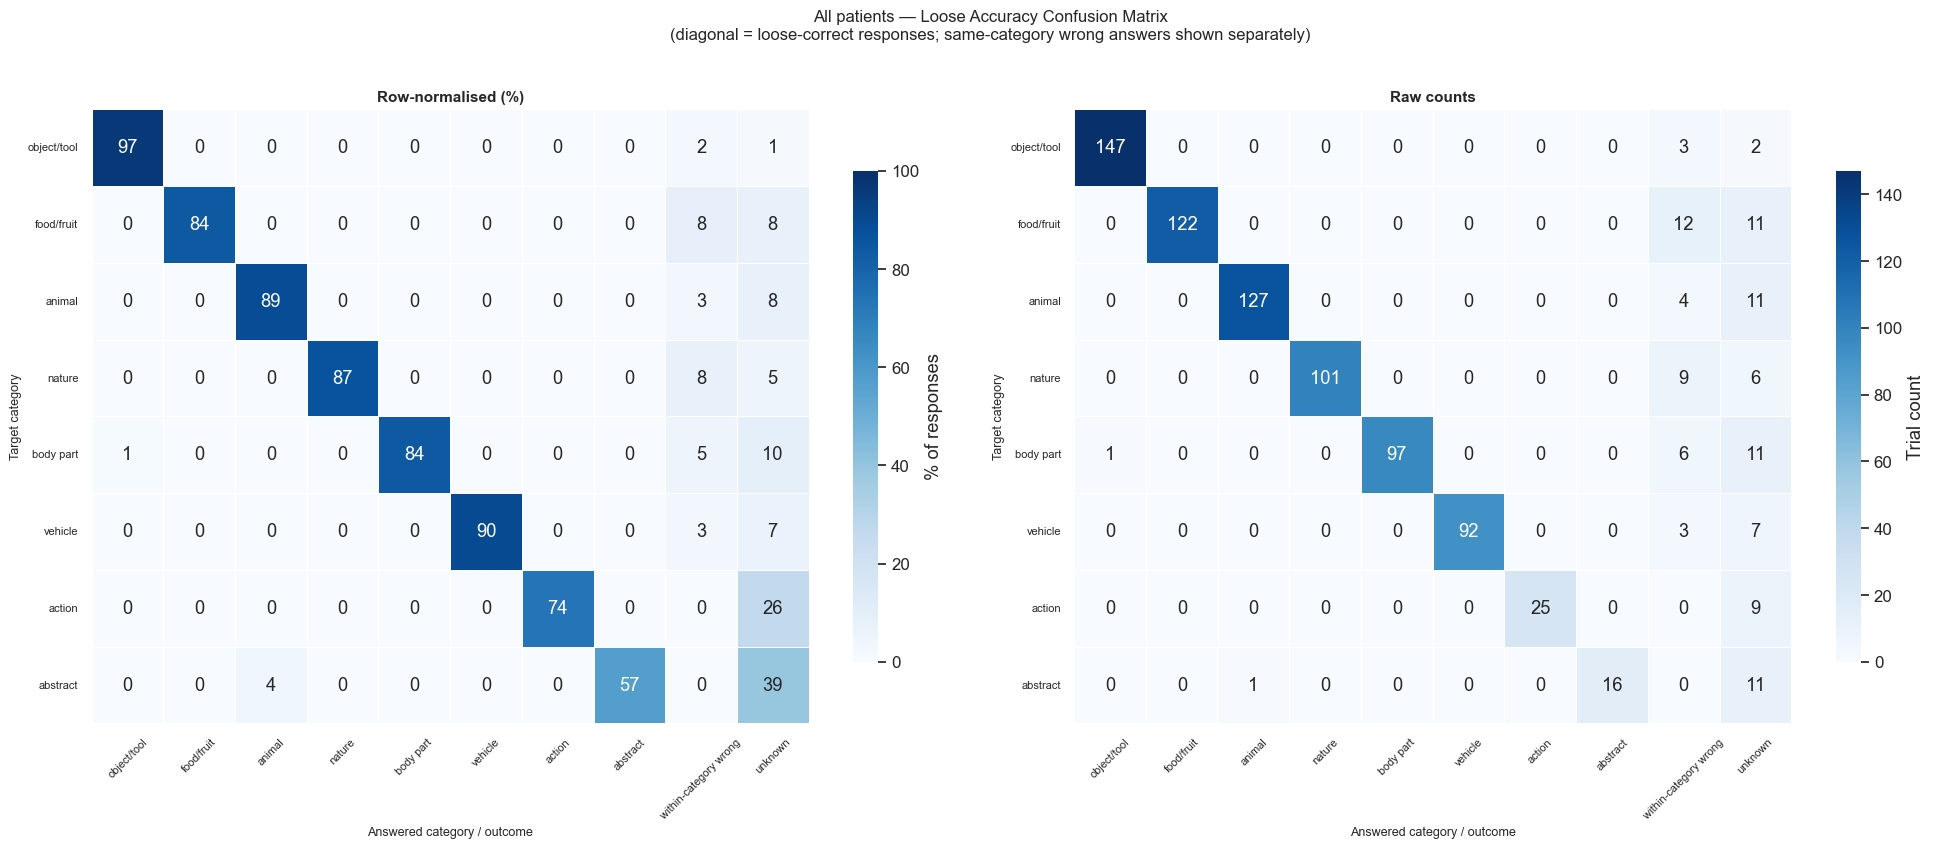

Diagonal accuracy per category (all patients):
             loose_acc_%  n_correct  n_total
object/tool         96.7        147      152
food/fruit          84.1        122      145
animal              89.4        127      142
nature              87.1        101      116
body part           84.3         97      115
vehicle             90.2         92      102
action              73.5         25       34
abstract            57.1         16       28


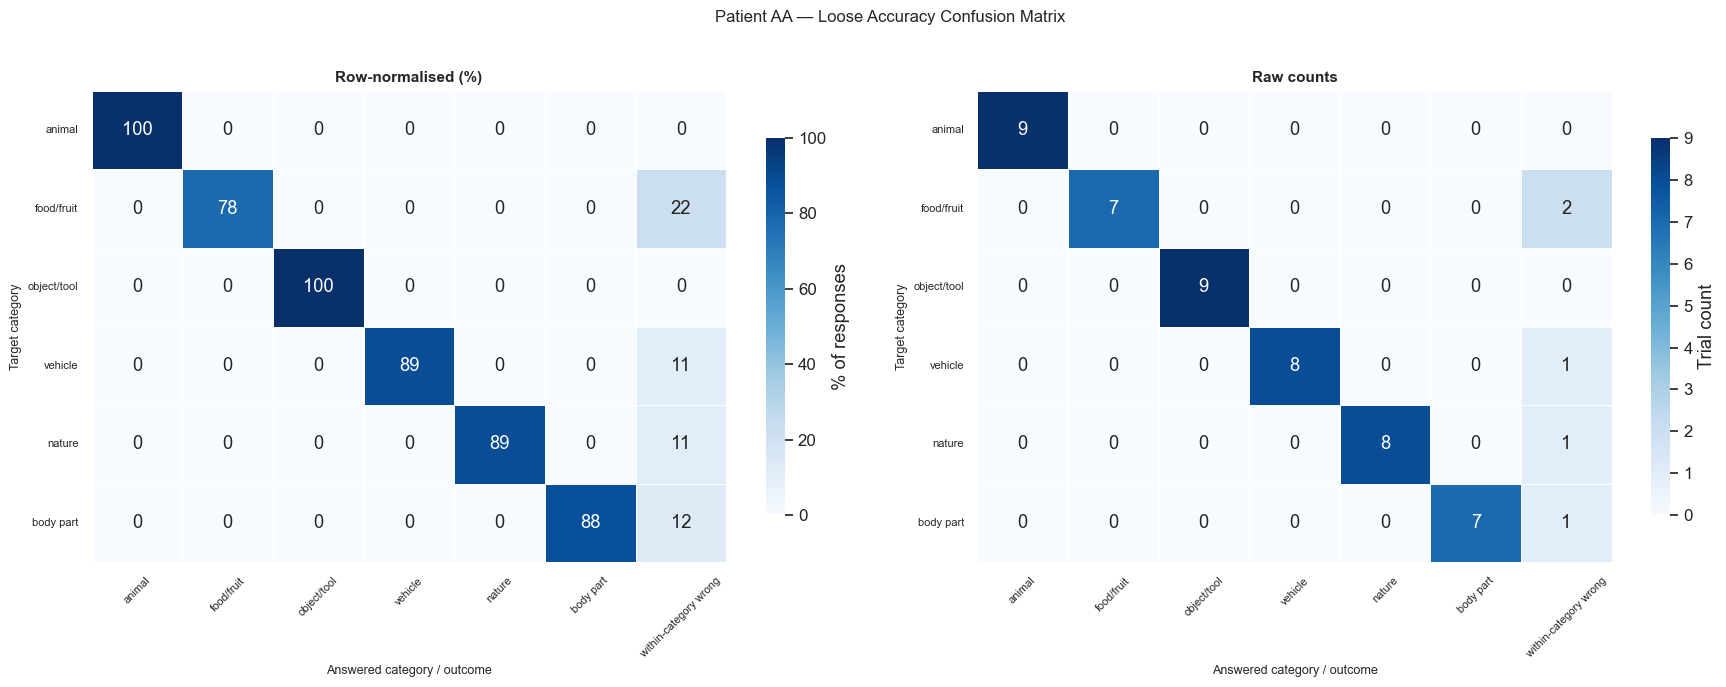

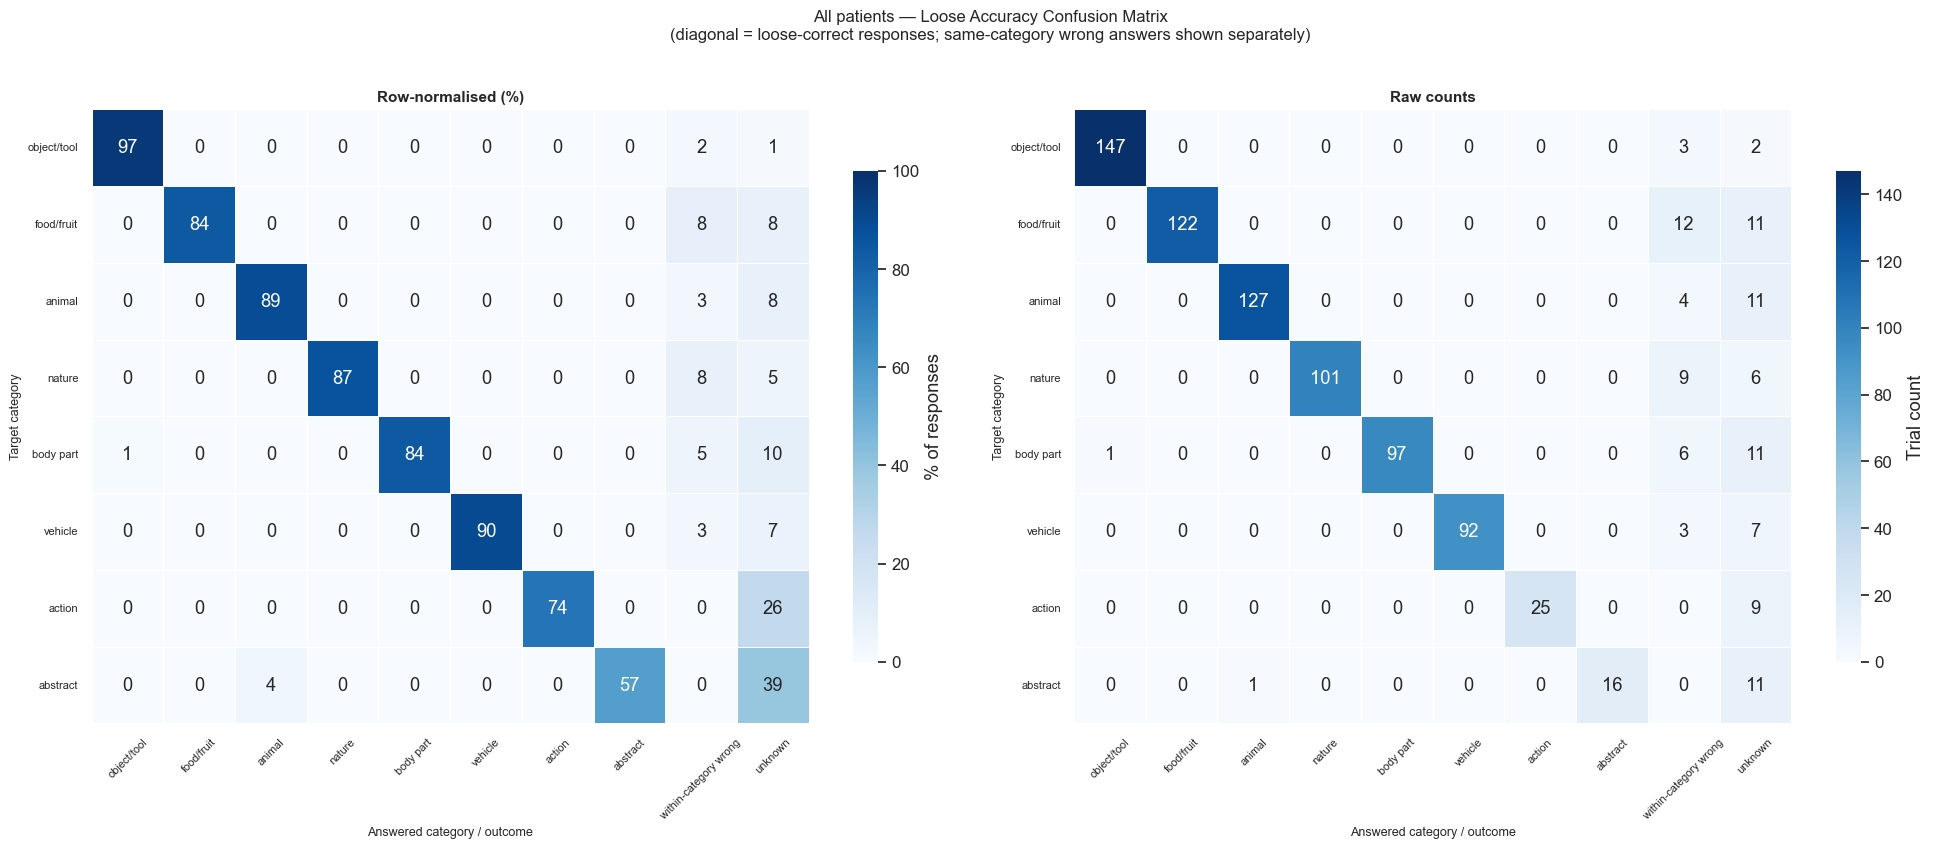

Diagonal accuracy per category (all patients):
             loose_acc_%  n_correct  n_total
object/tool         96.7        147      152
food/fruit          84.1        122      145
animal              89.4        127      142
nature              87.1        101      116
body part           84.3         97      115
vehicle             90.2         92      102
action              73.5         25       34
abstract            57.1         16       28


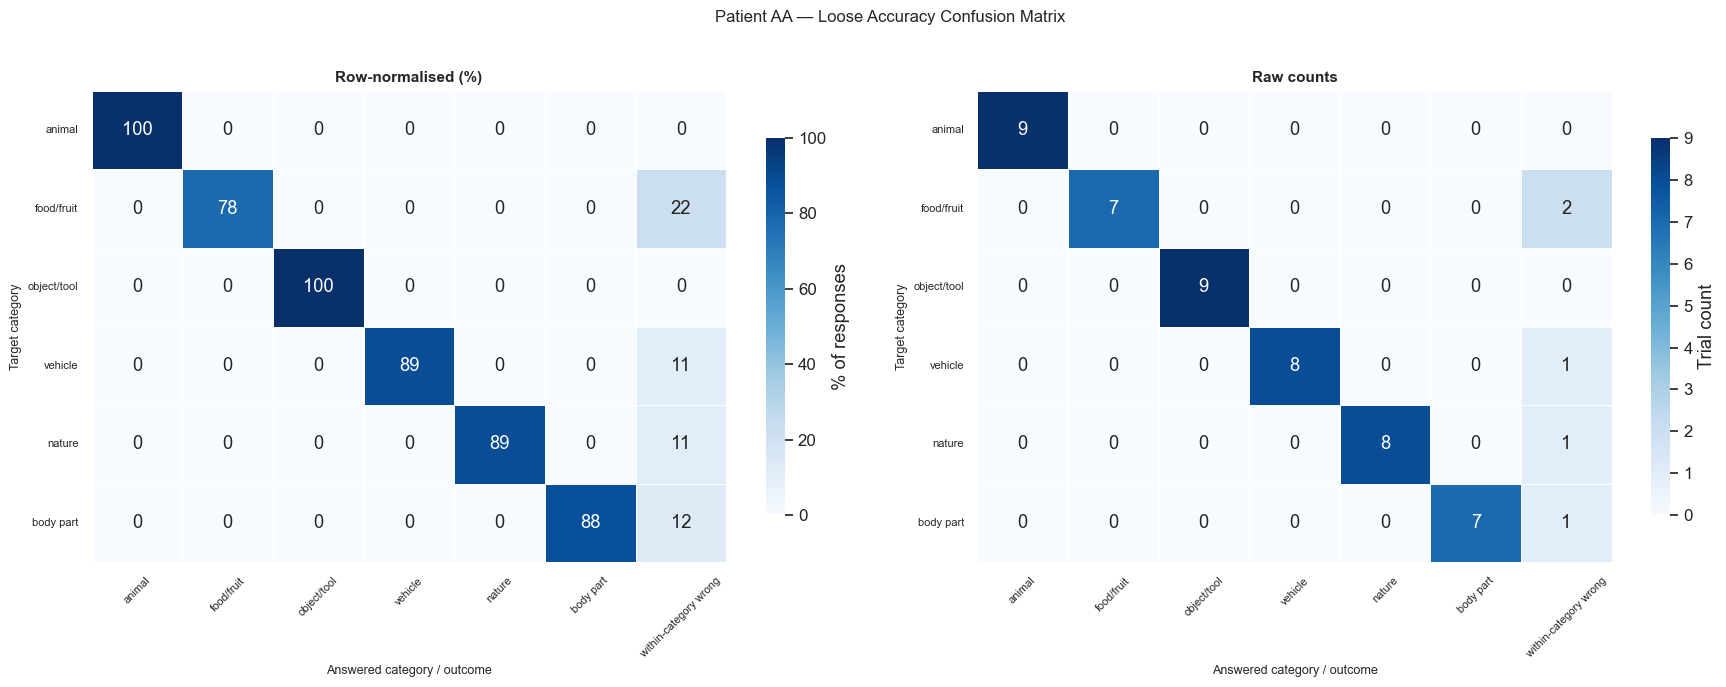

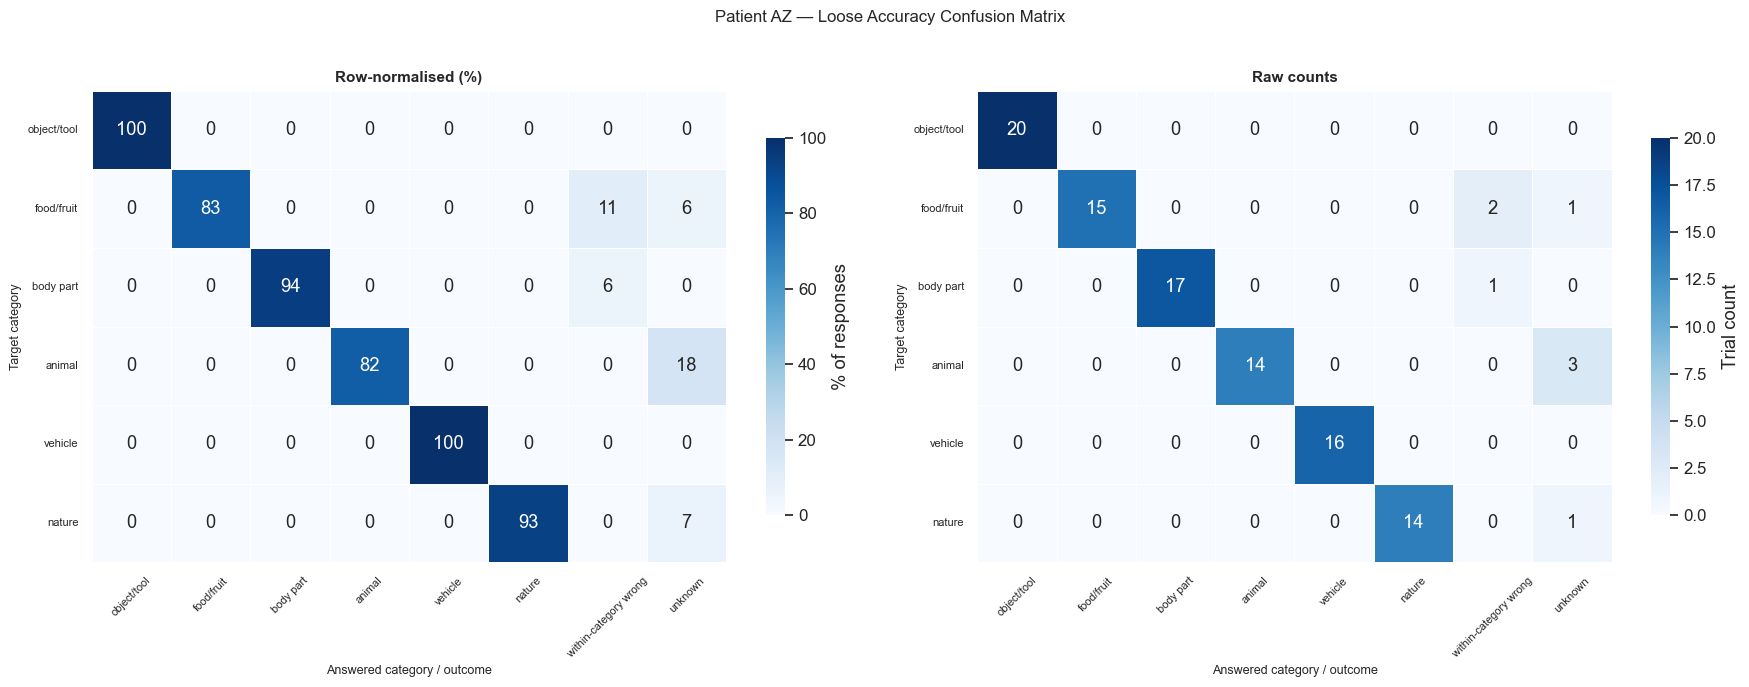

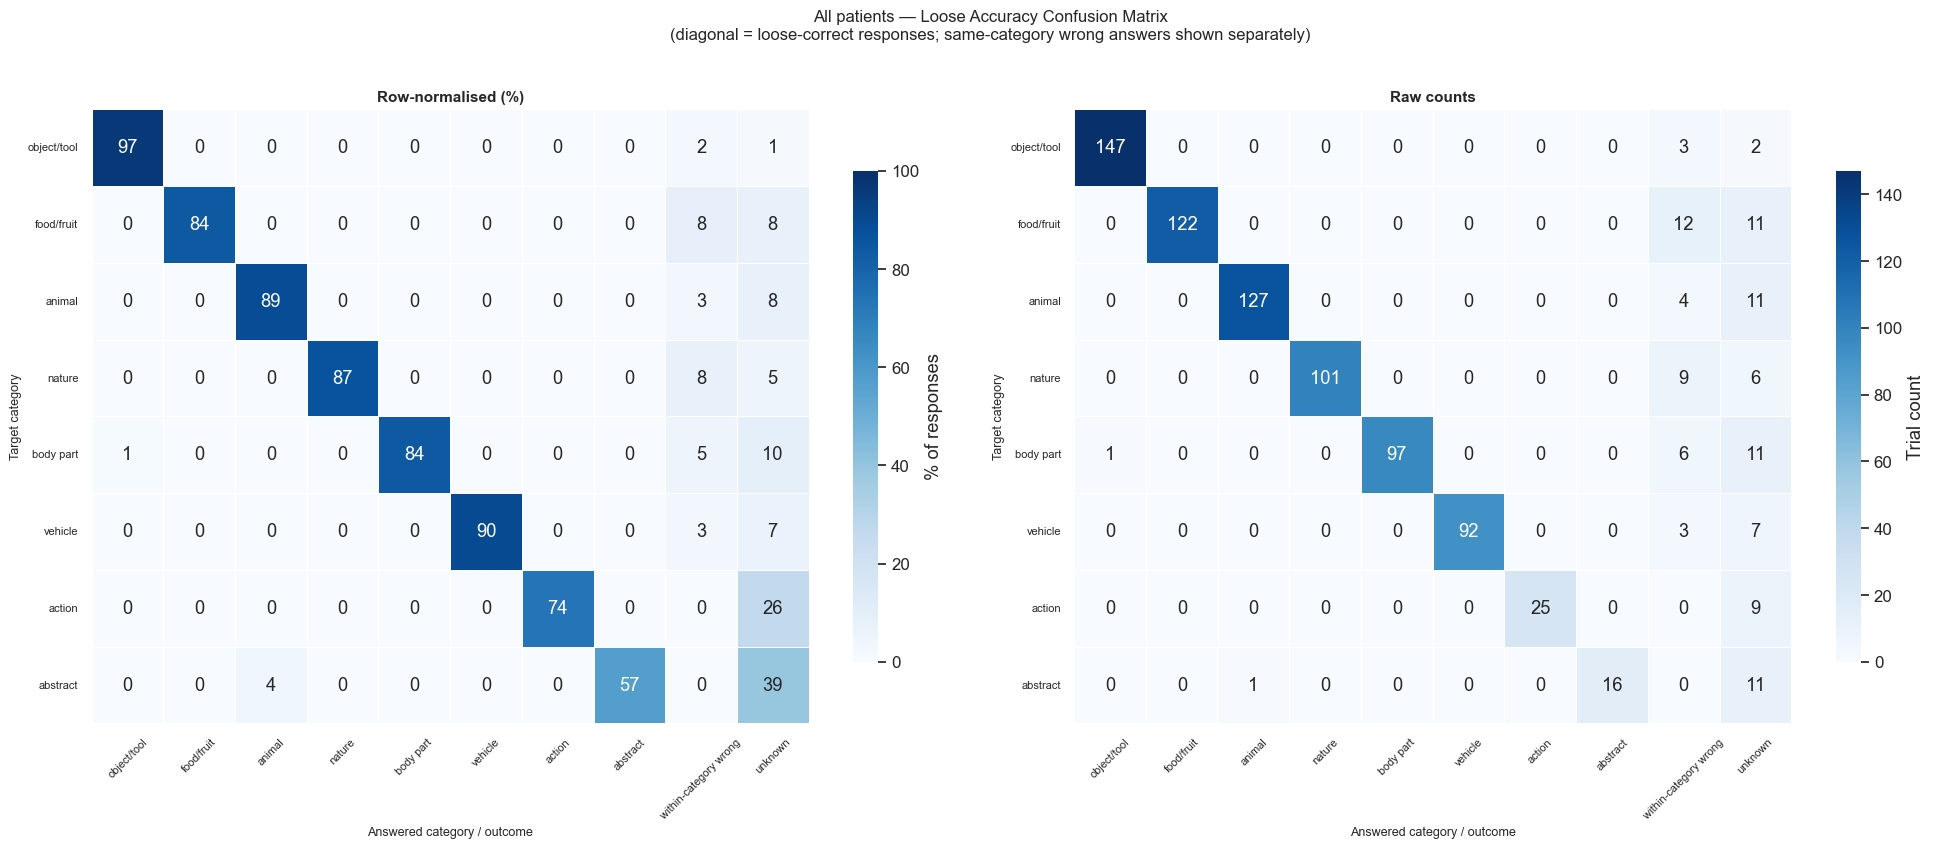

Diagonal accuracy per category (all patients):
             loose_acc_%  n_correct  n_total
object/tool         96.7        147      152
food/fruit          84.1        122      145
animal              89.4        127      142
nature              87.1        101      116
body part           84.3         97      115
vehicle             90.2         92      102
action              73.5         25       34
abstract            57.1         16       28


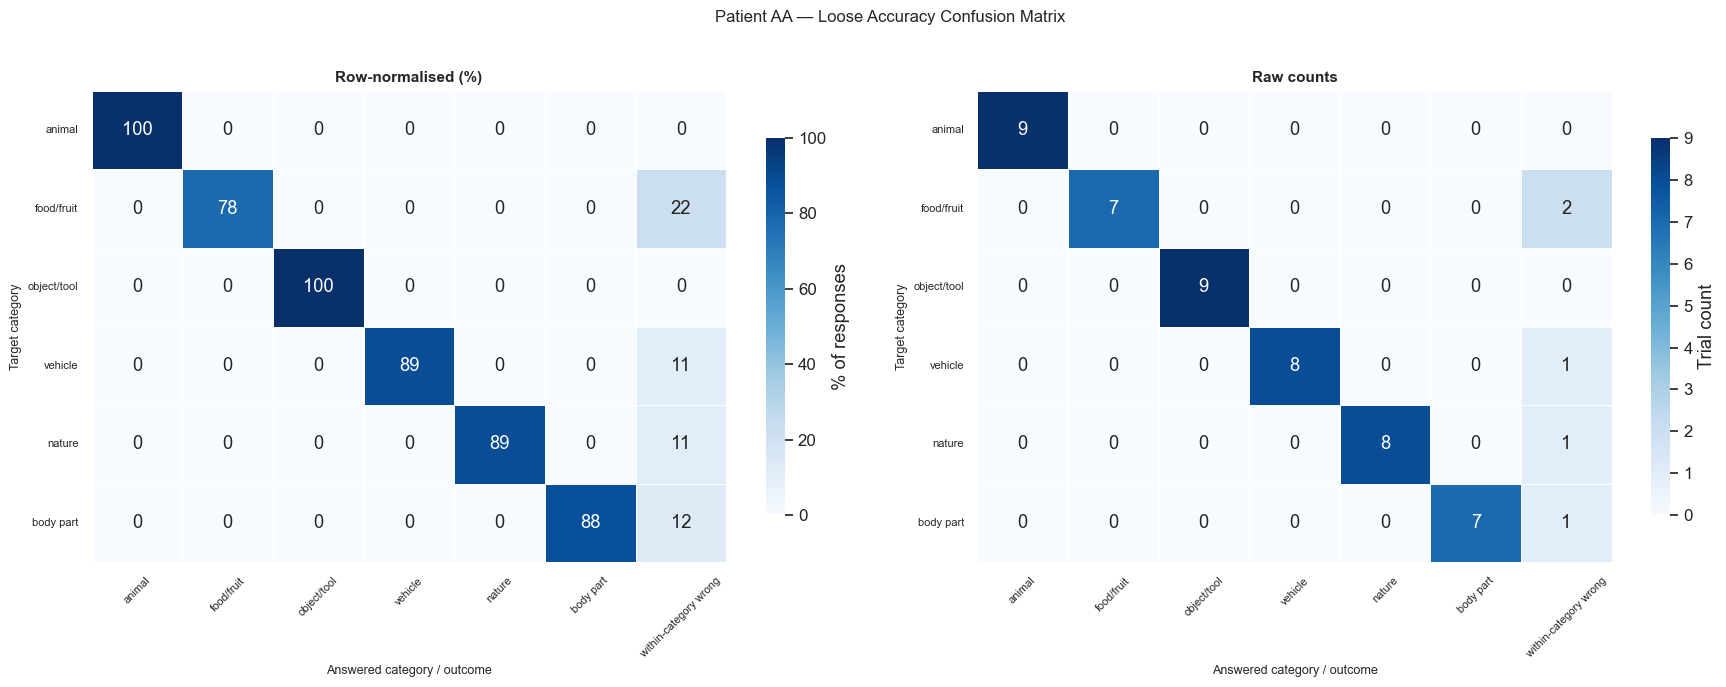

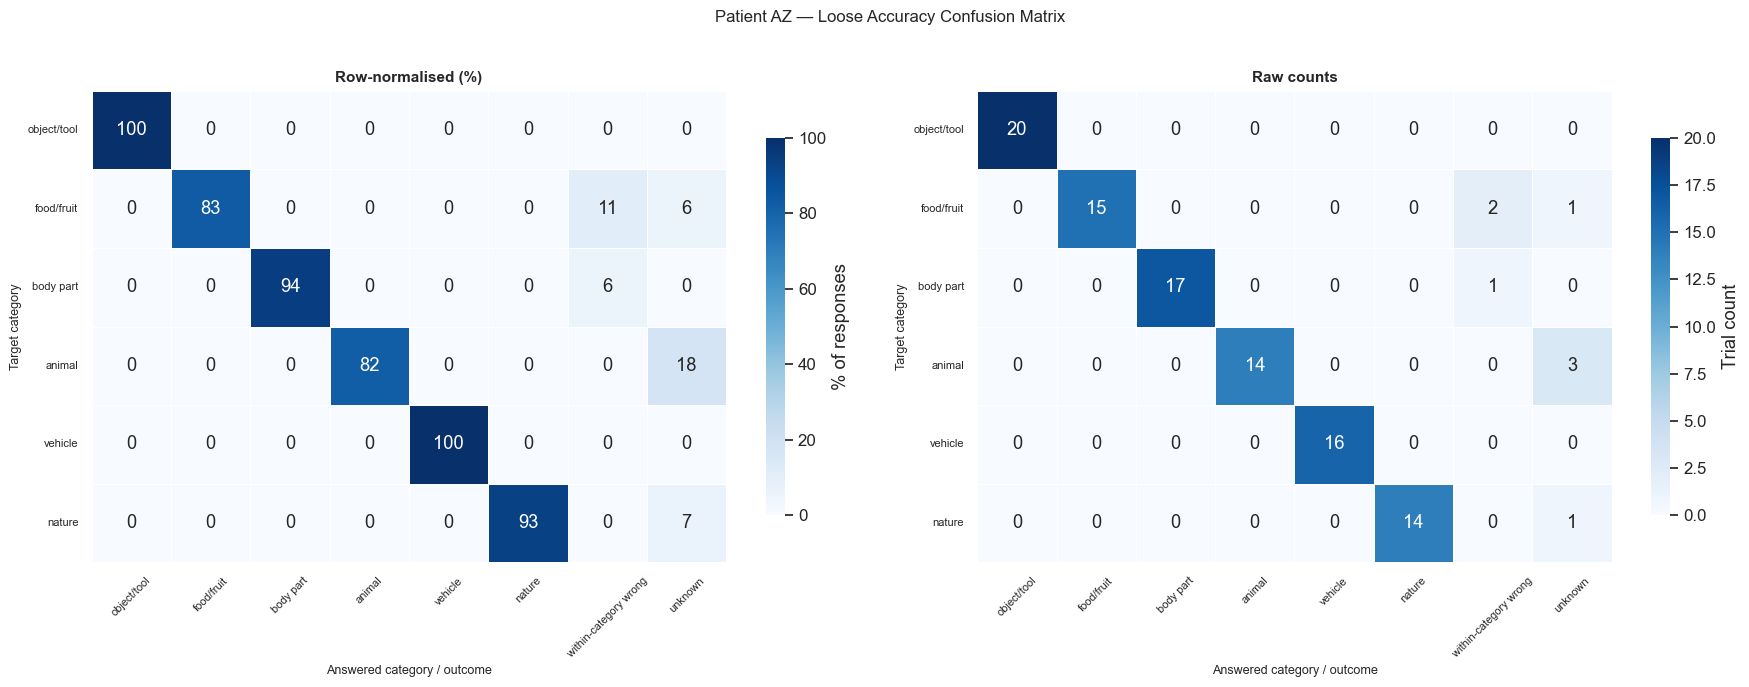

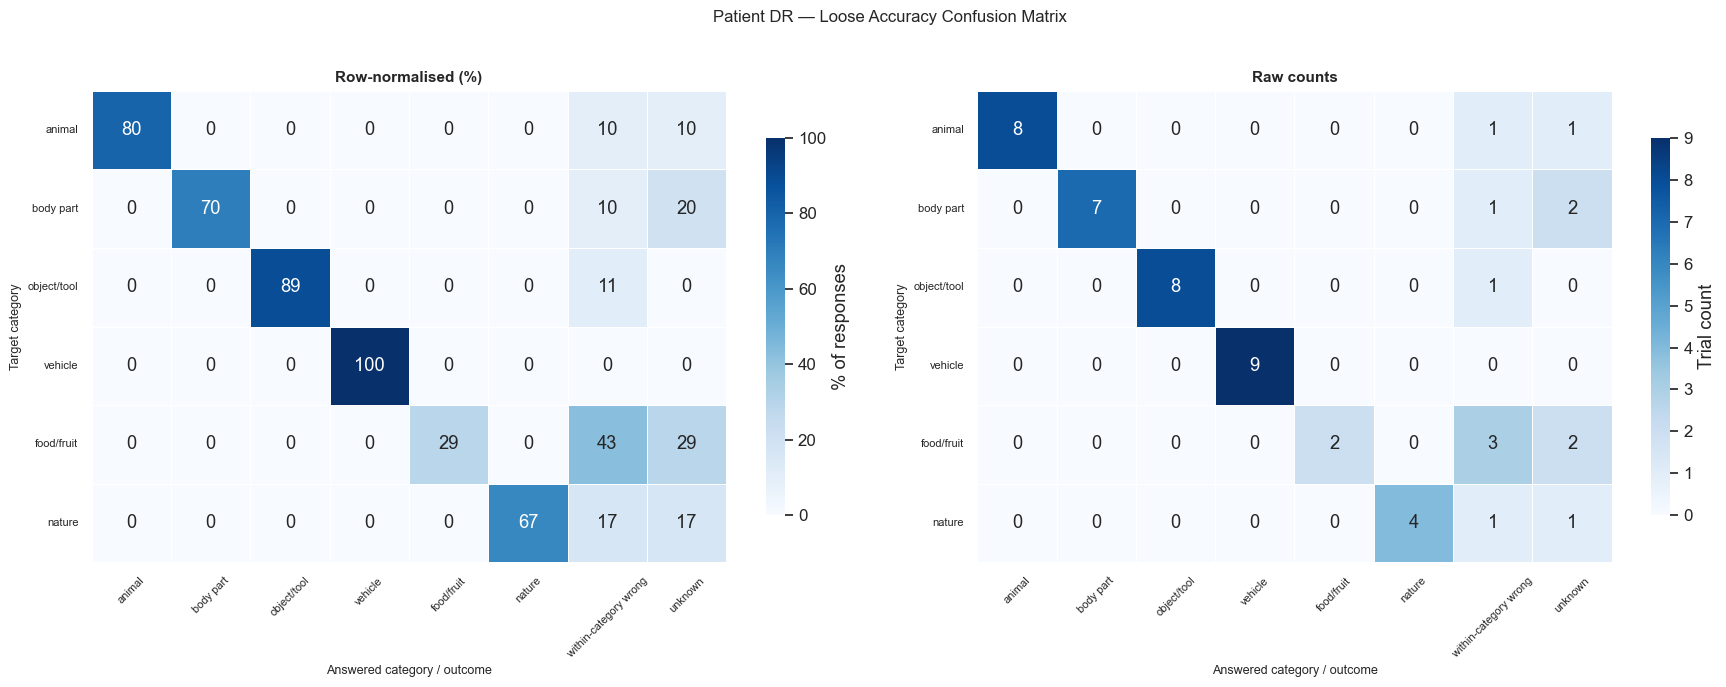

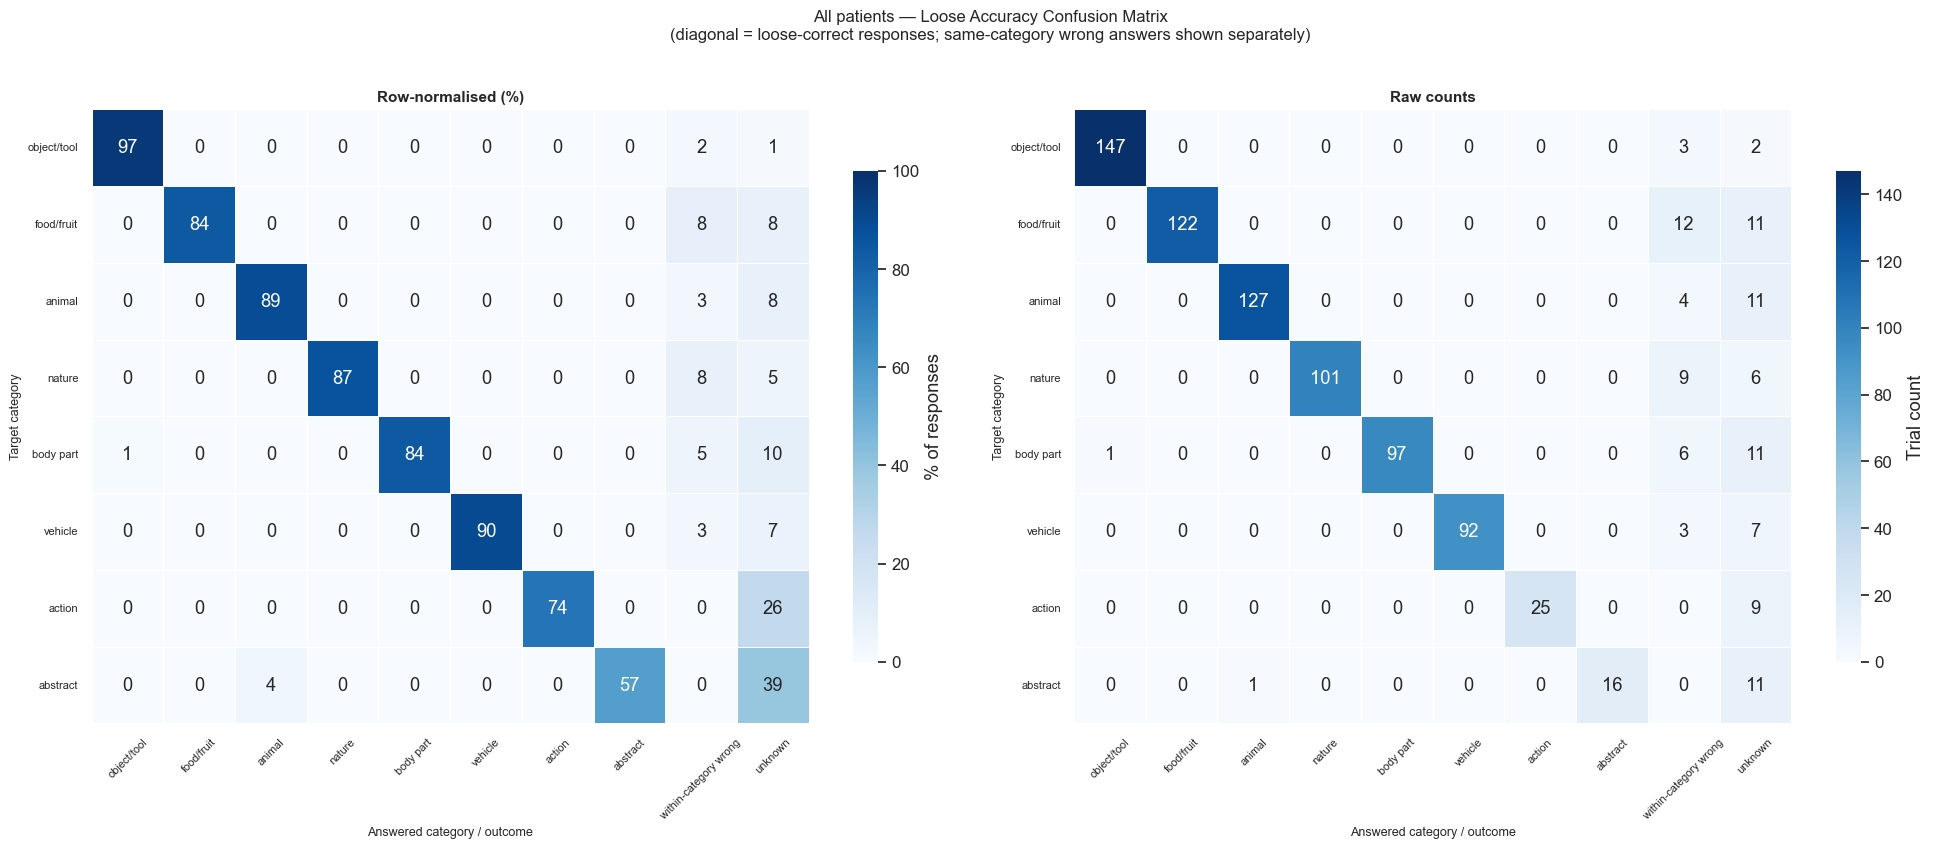

Diagonal accuracy per category (all patients):
             loose_acc_%  n_correct  n_total
object/tool         96.7        147      152
food/fruit          84.1        122      145
animal              89.4        127      142
nature              87.1        101      116
body part           84.3         97      115
vehicle             90.2         92      102
action              73.5         25       34
abstract            57.1         16       28


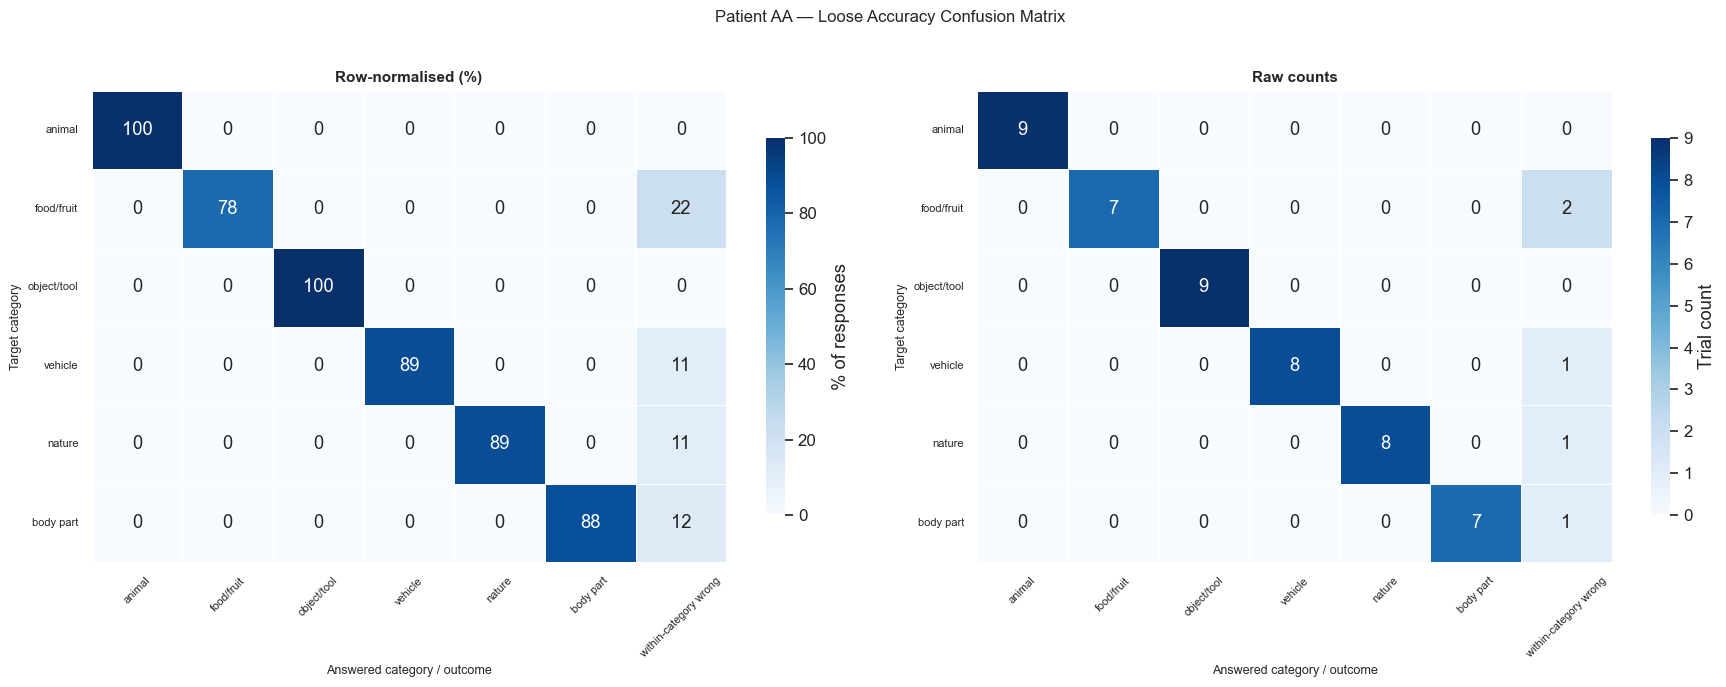

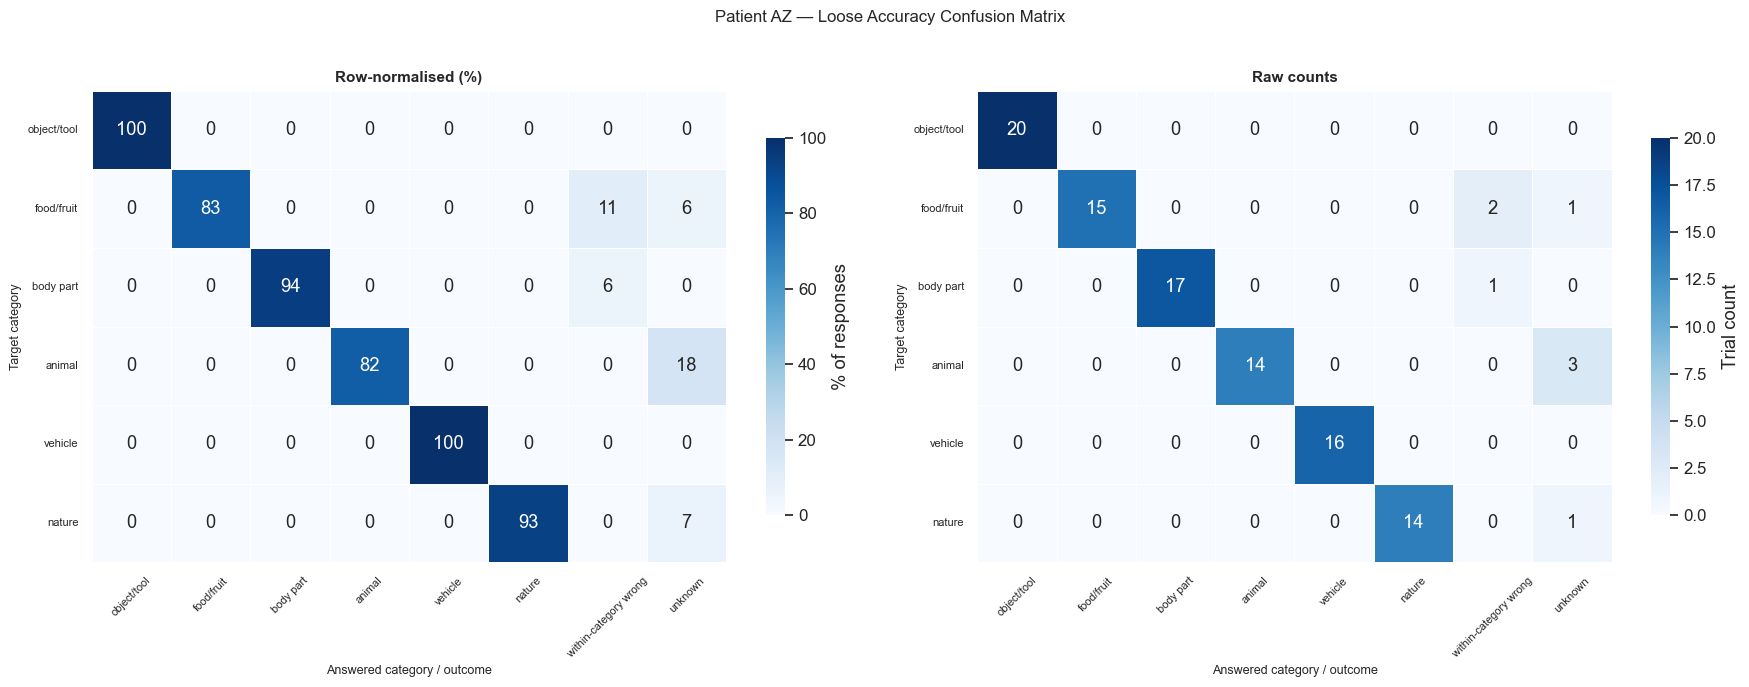

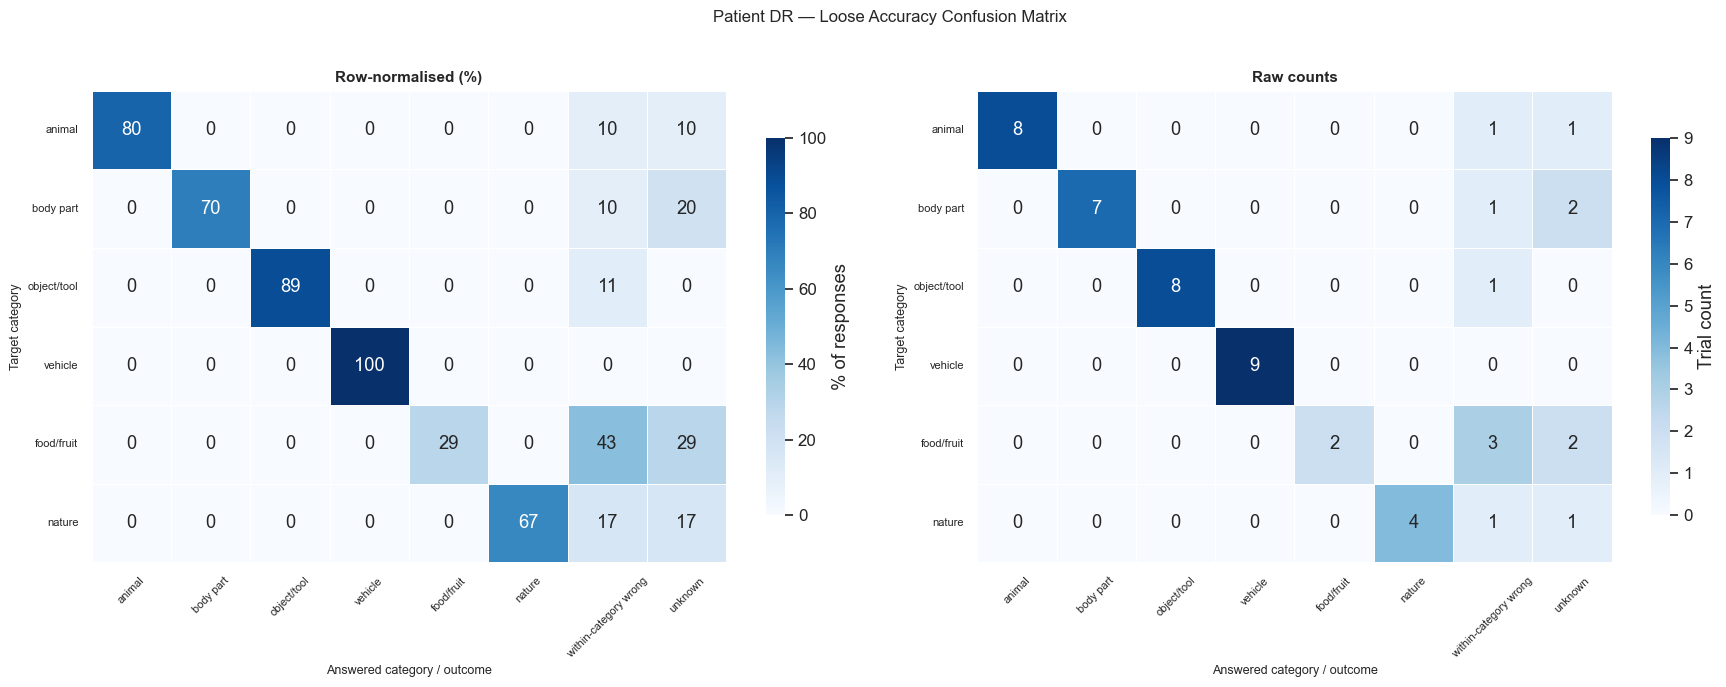

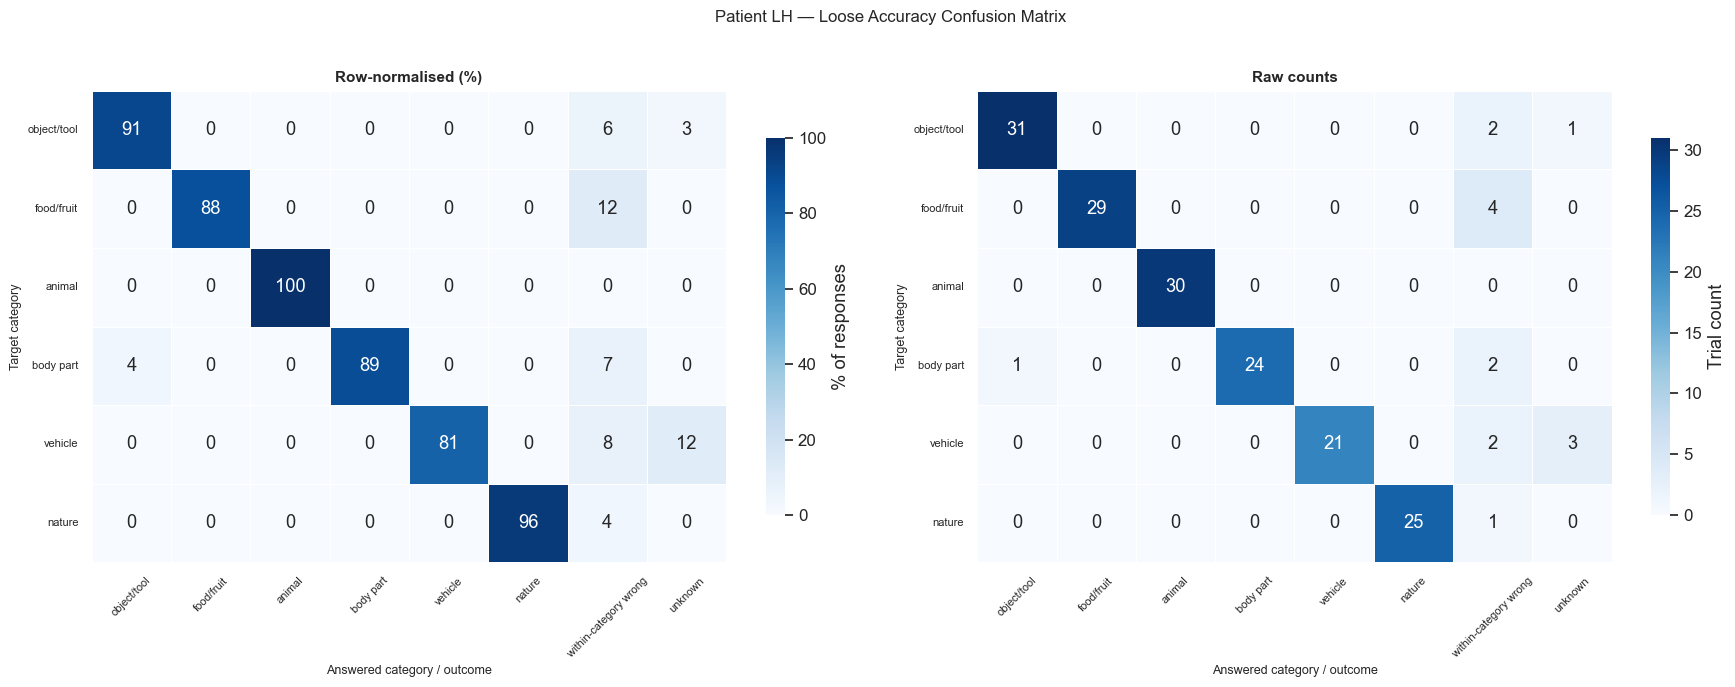

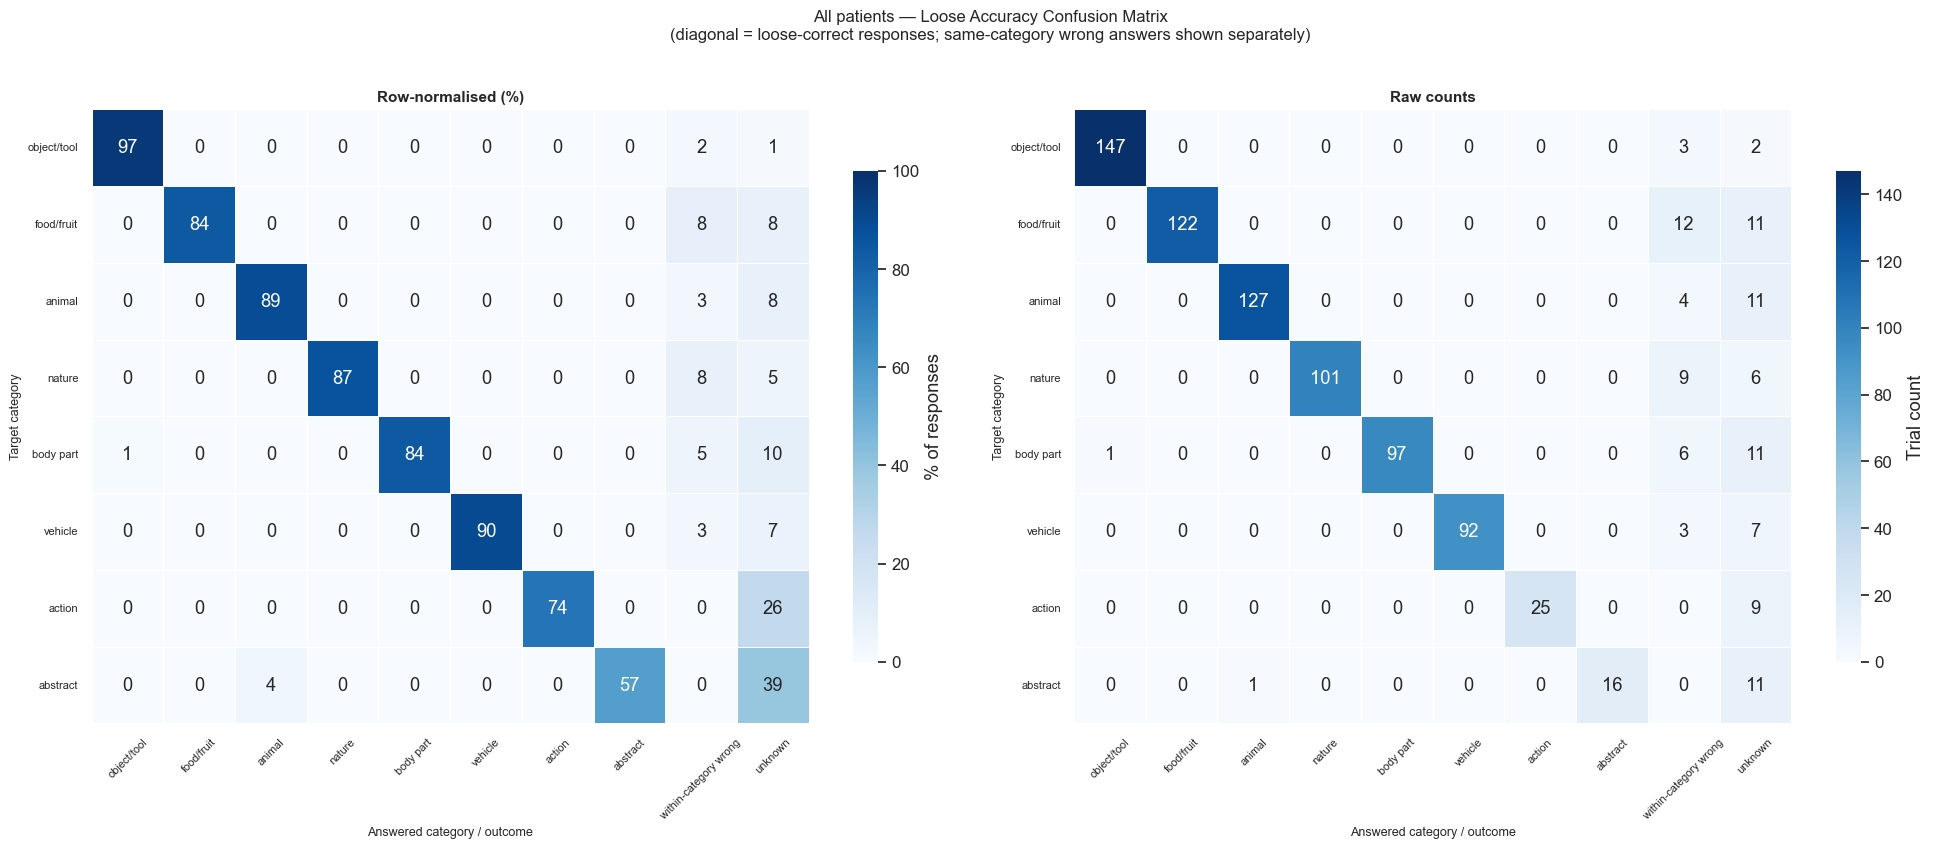

Diagonal accuracy per category (all patients):
             loose_acc_%  n_correct  n_total
object/tool         96.7        147      152
food/fruit          84.1        122      145
animal              89.4        127      142
nature              87.1        101      116
body part           84.3         97      115
vehicle             90.2         92      102
action              73.5         25       34
abstract            57.1         16       28


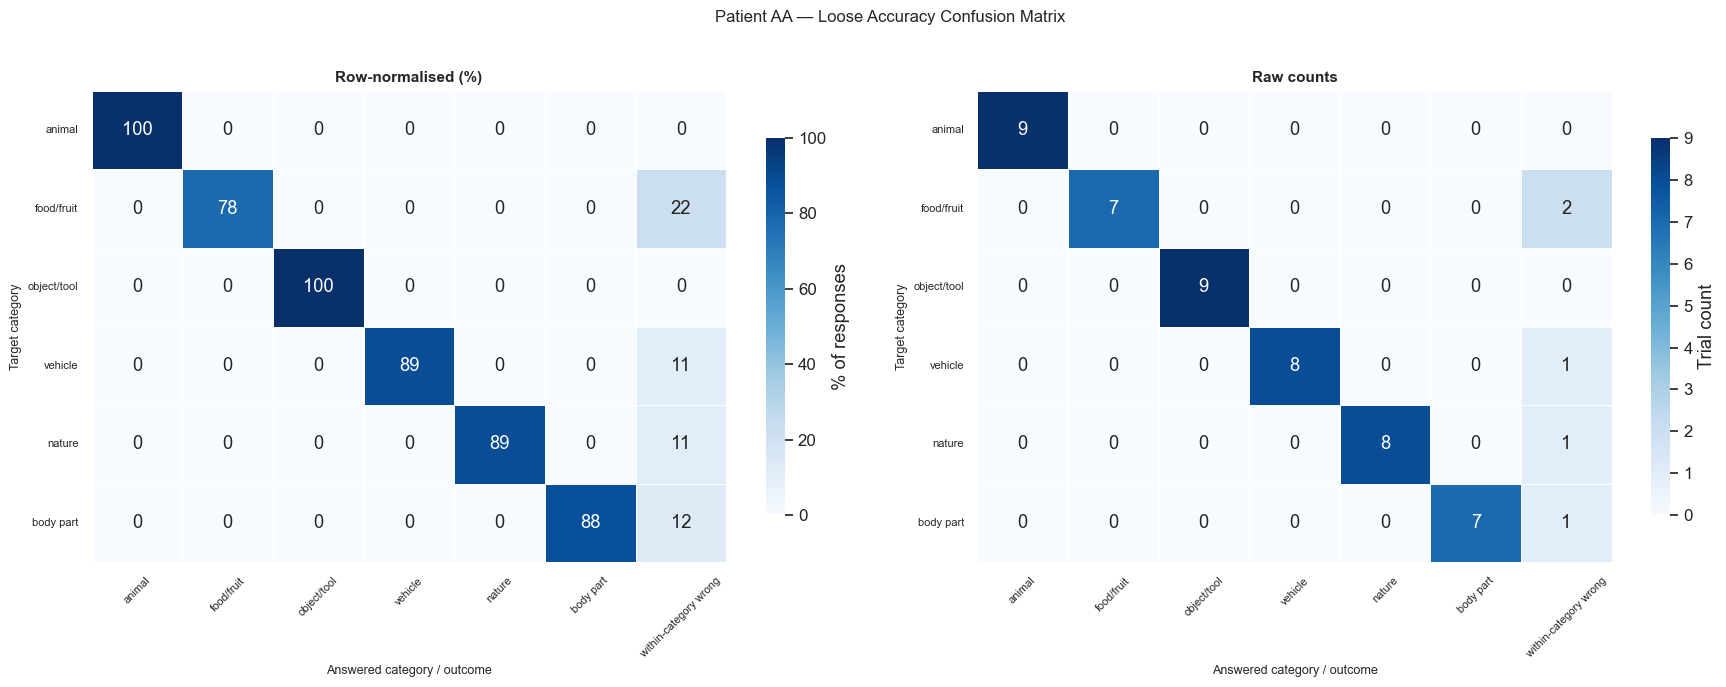

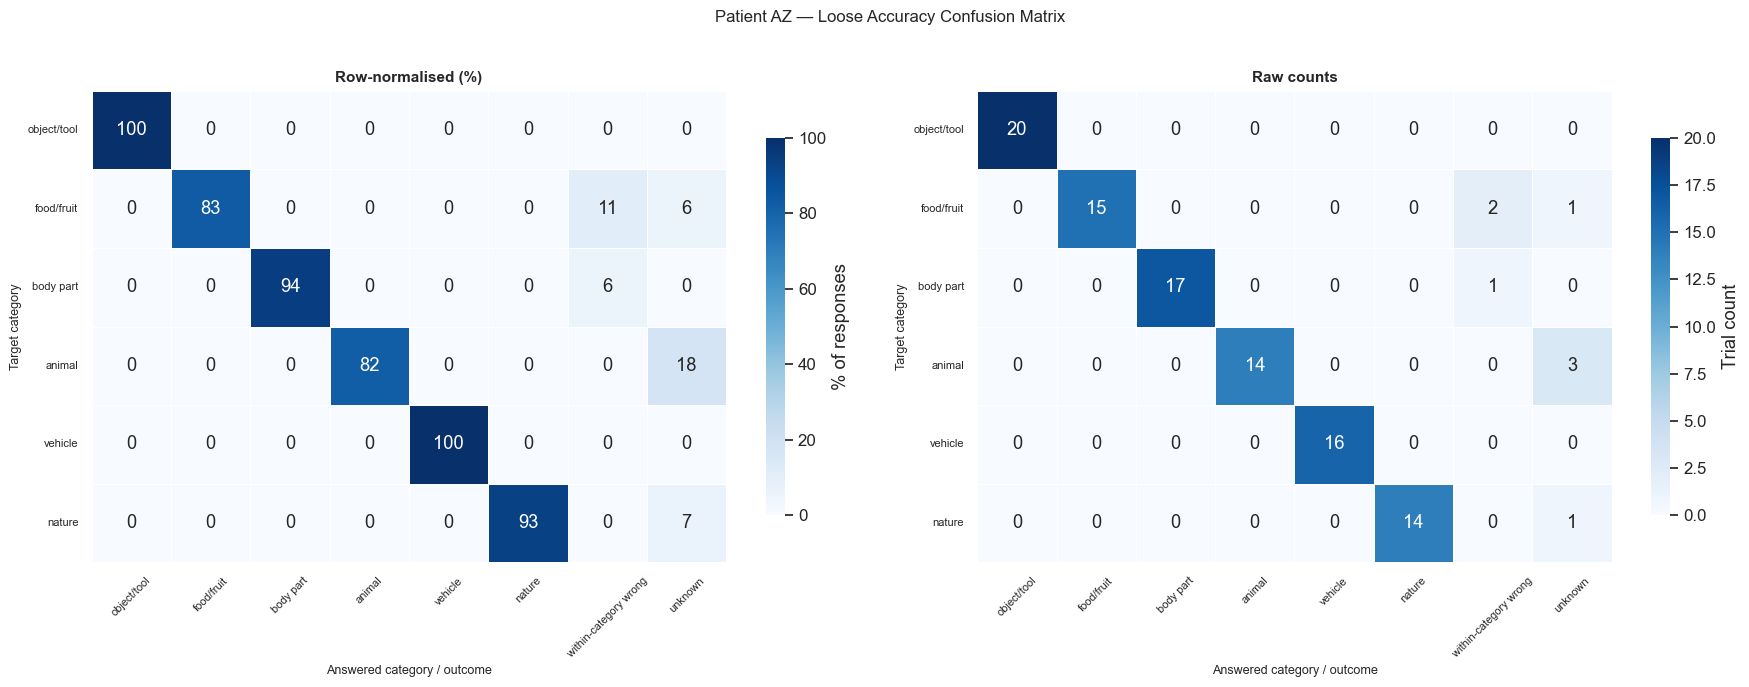

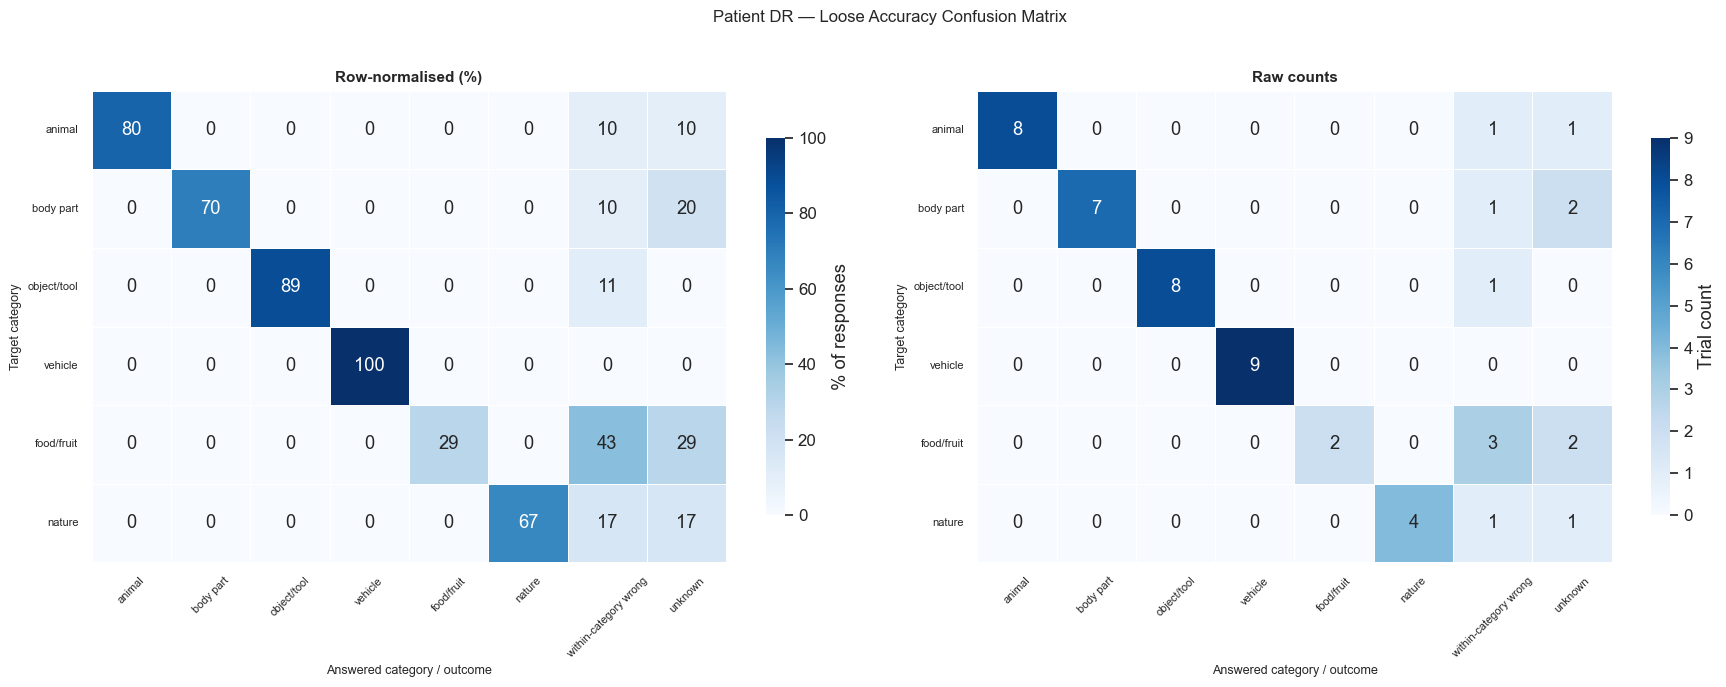

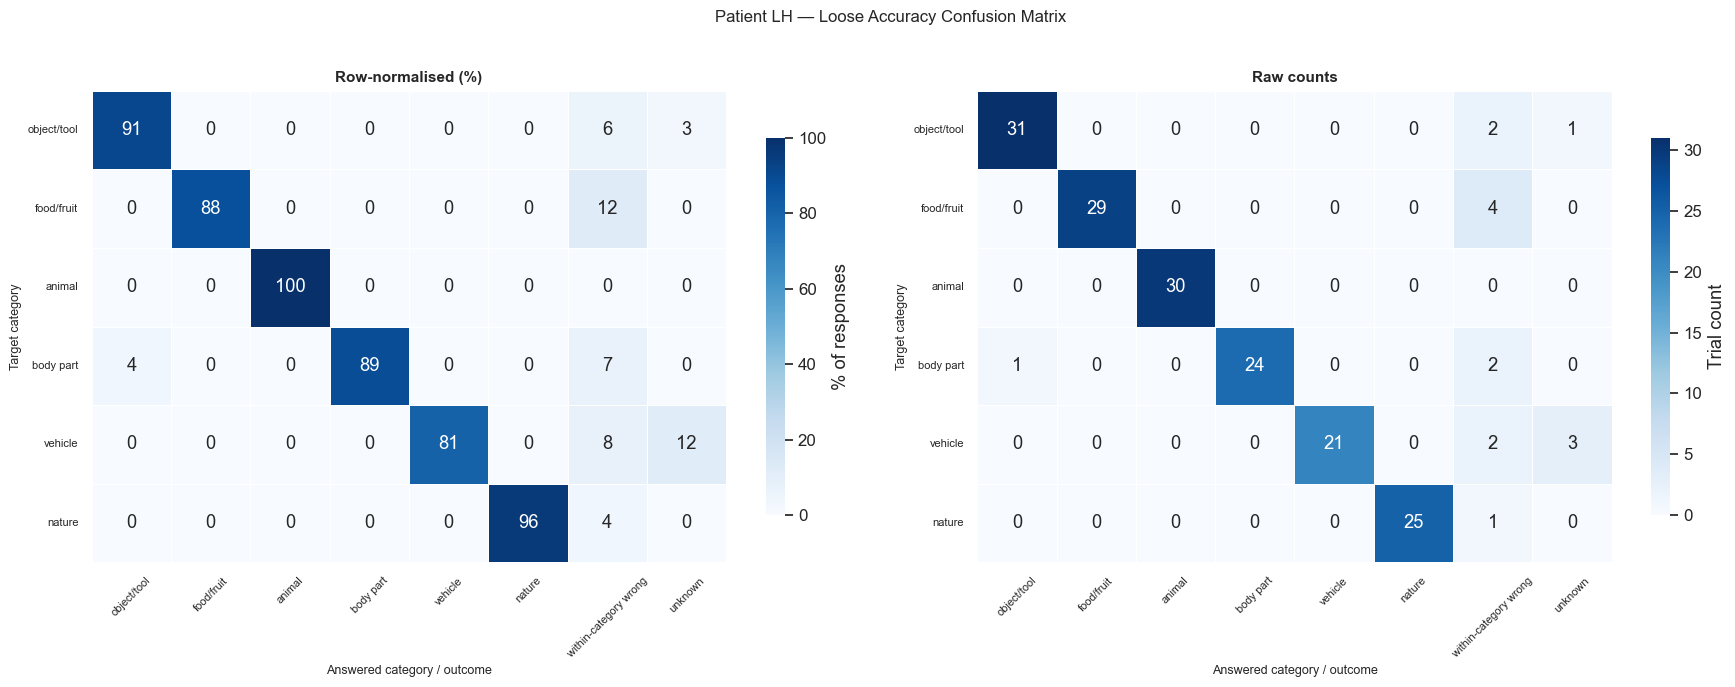

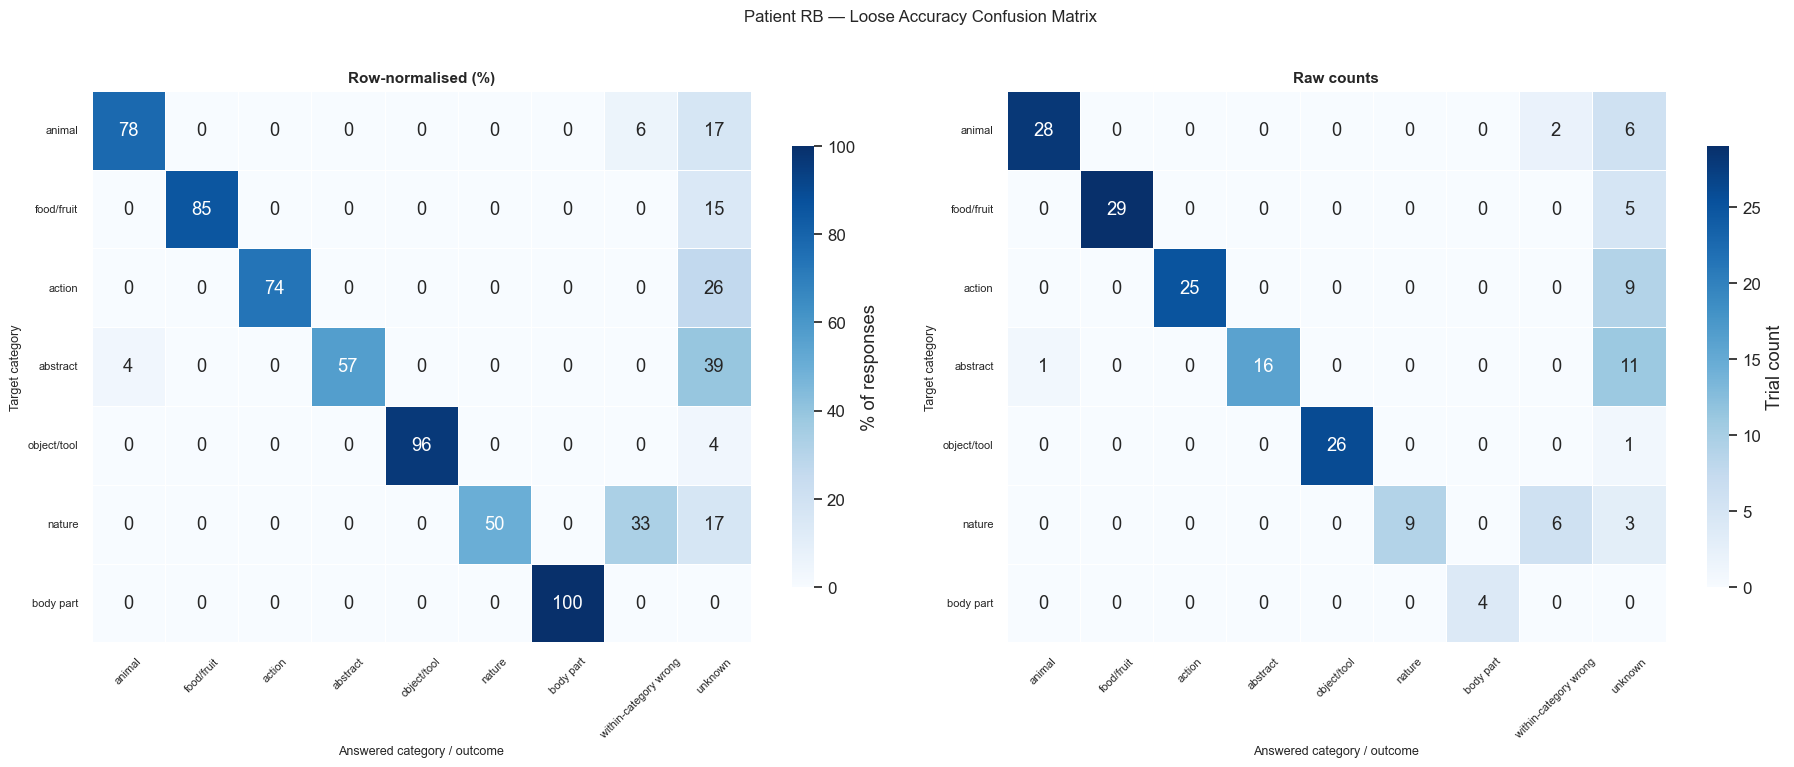

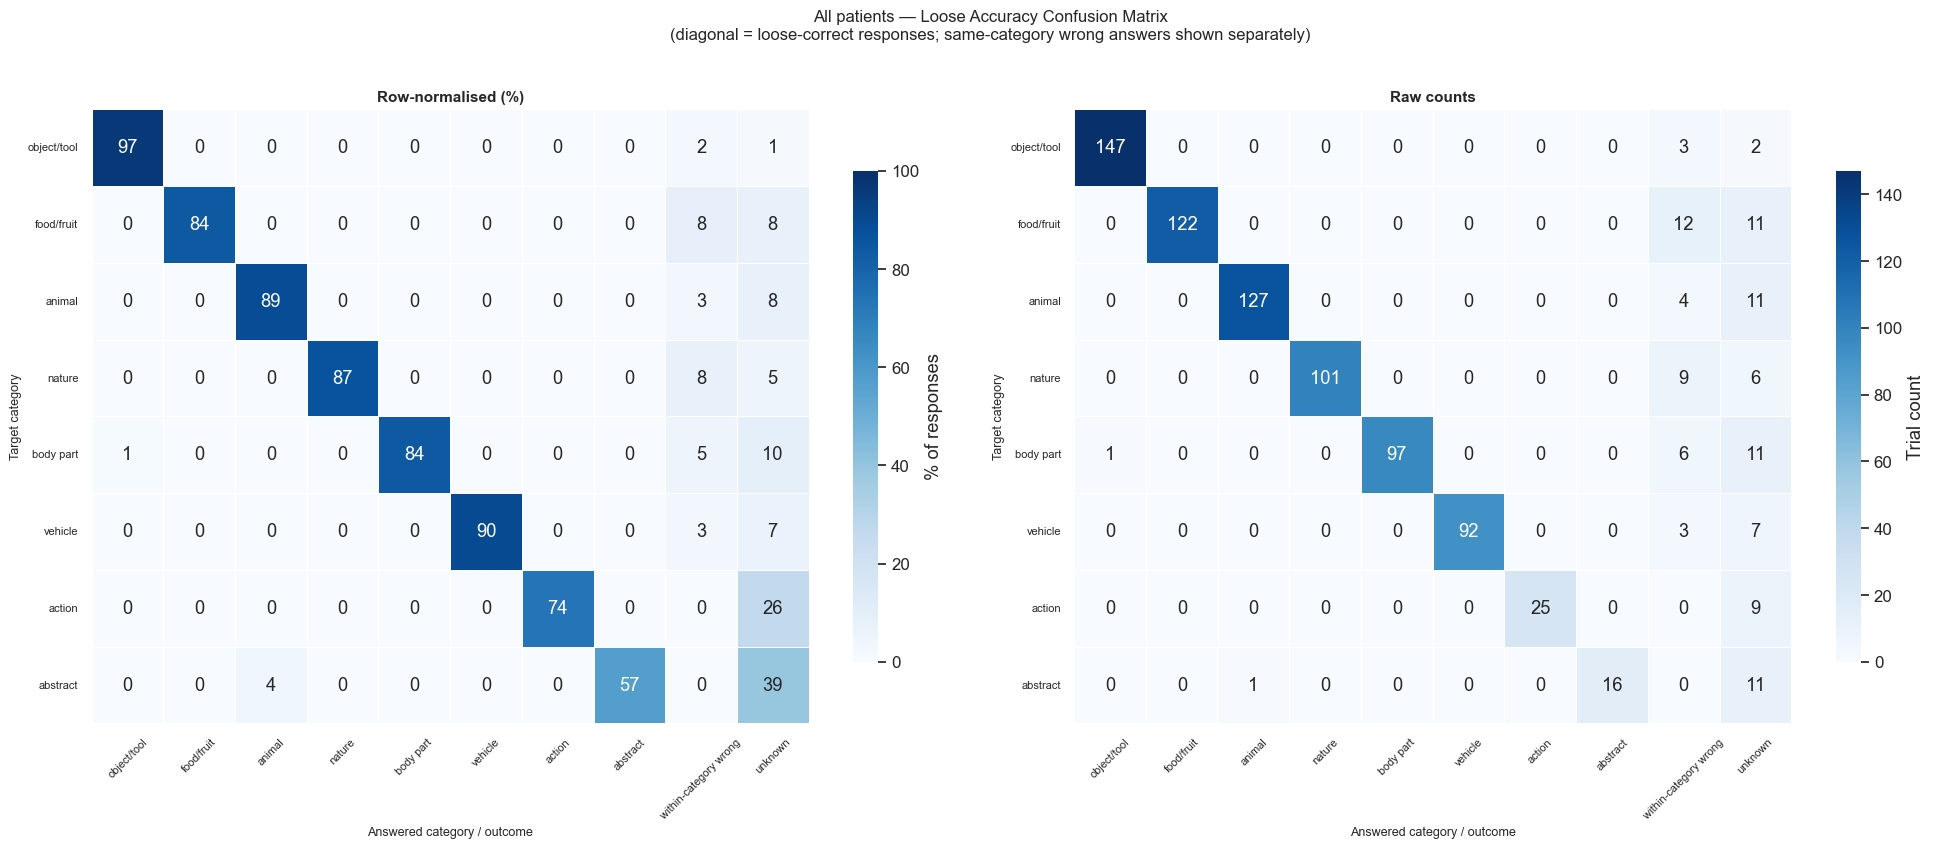

Diagonal accuracy per category (all patients):
             loose_acc_%  n_correct  n_total
object/tool         96.7        147      152
food/fruit          84.1        122      145
animal              89.4        127      142
nature              87.1        101      116
body part           84.3         97      115
vehicle             90.2         92      102
action              73.5         25       34
abstract            57.1         16       28


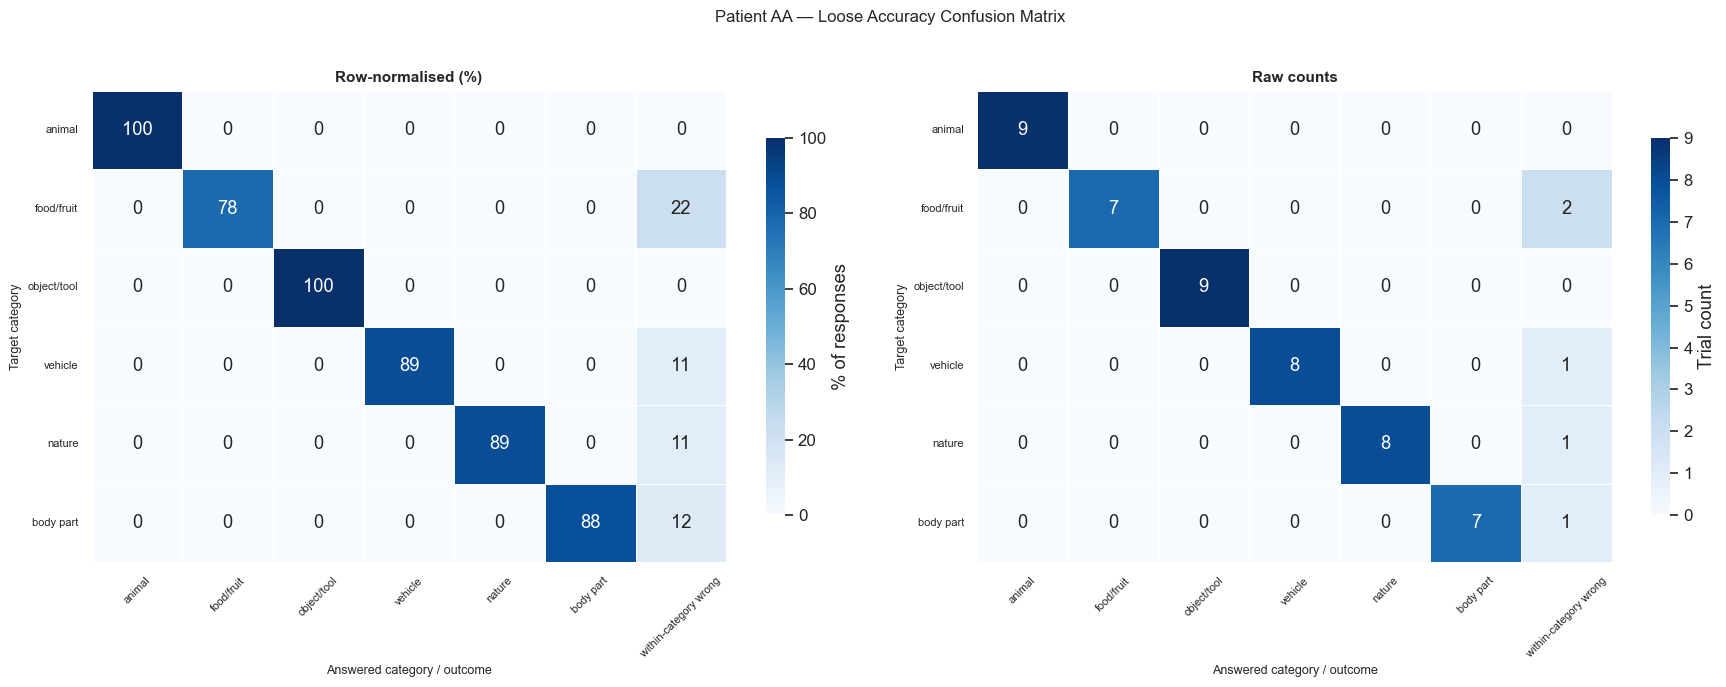

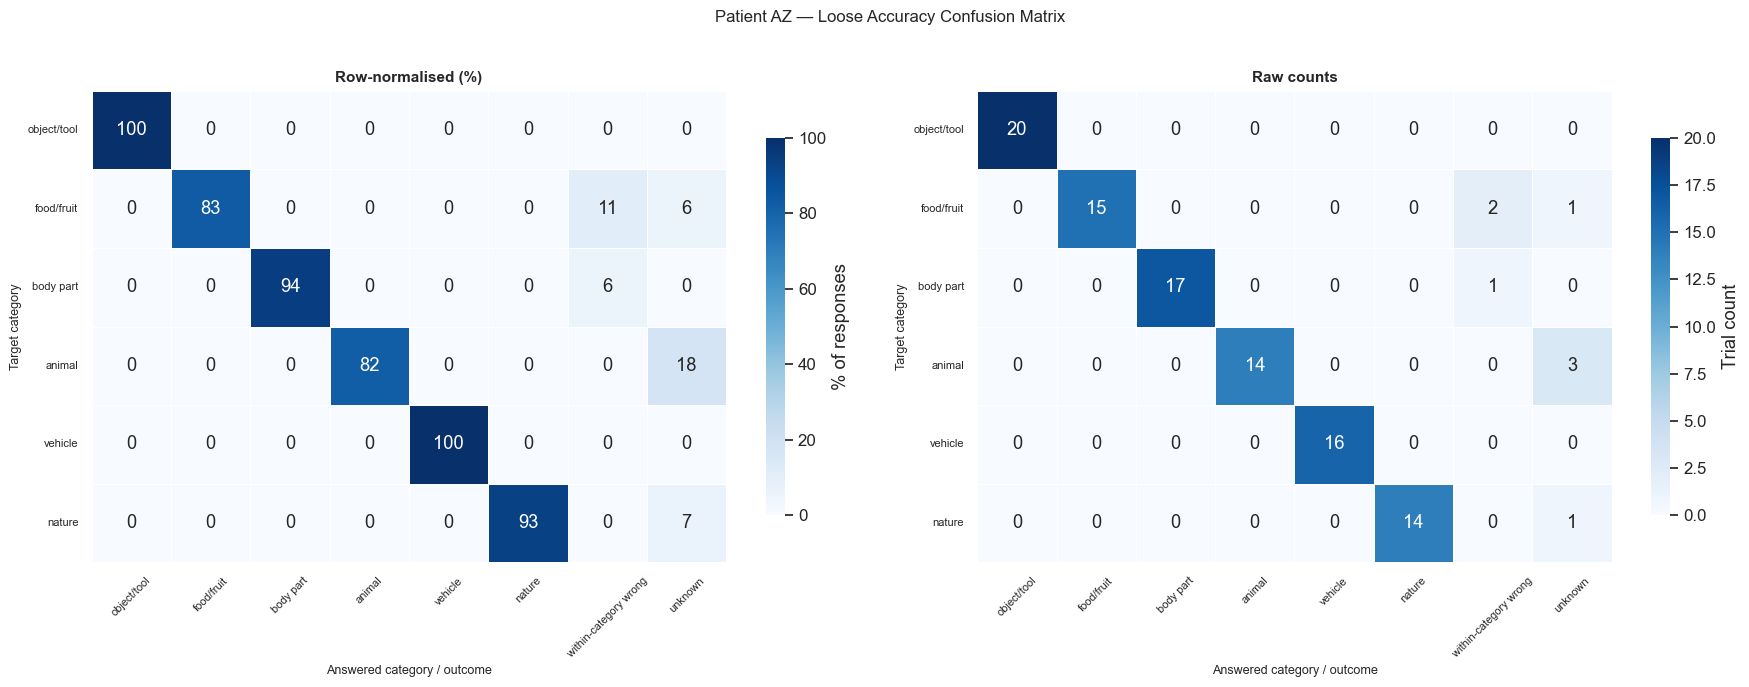

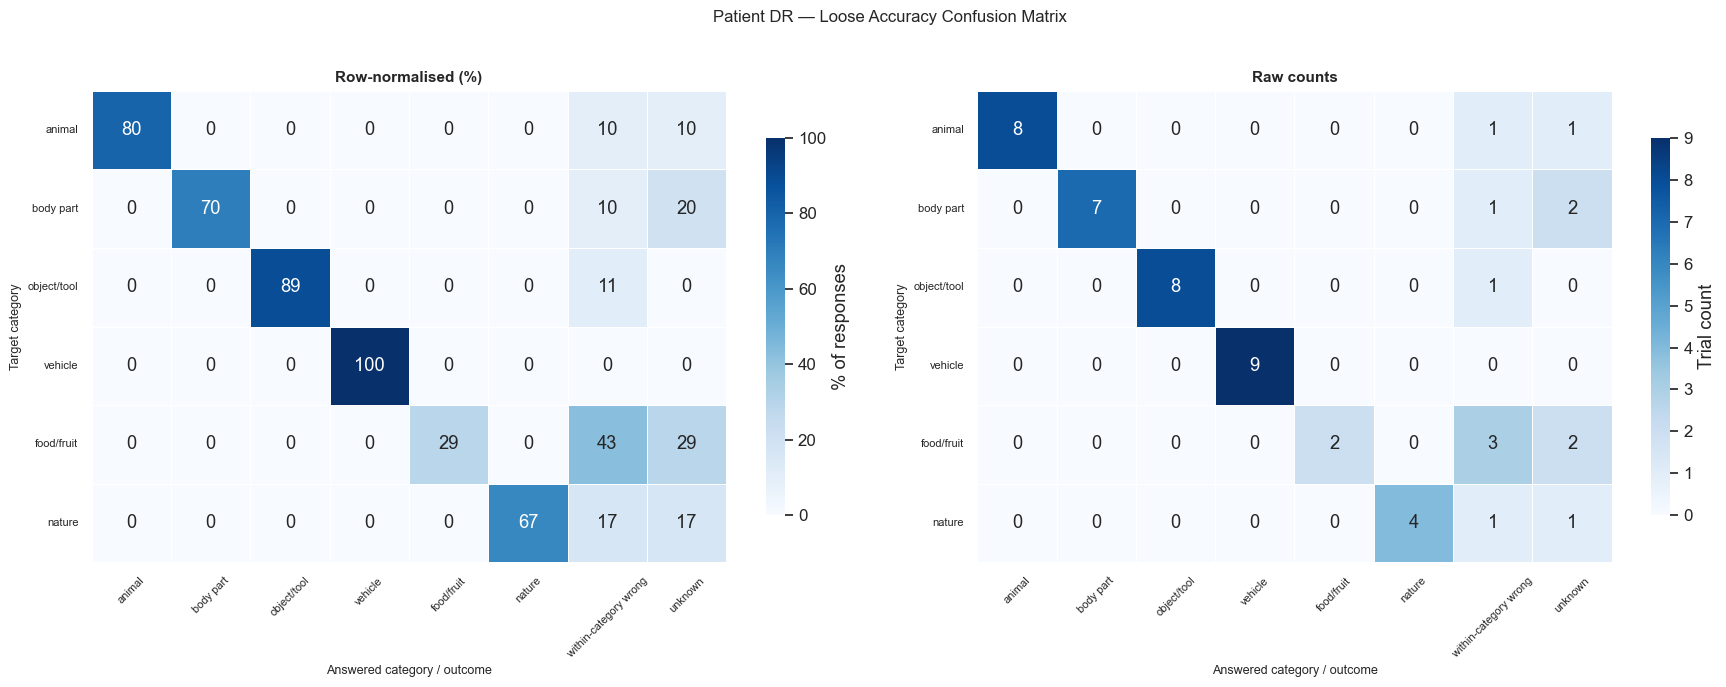

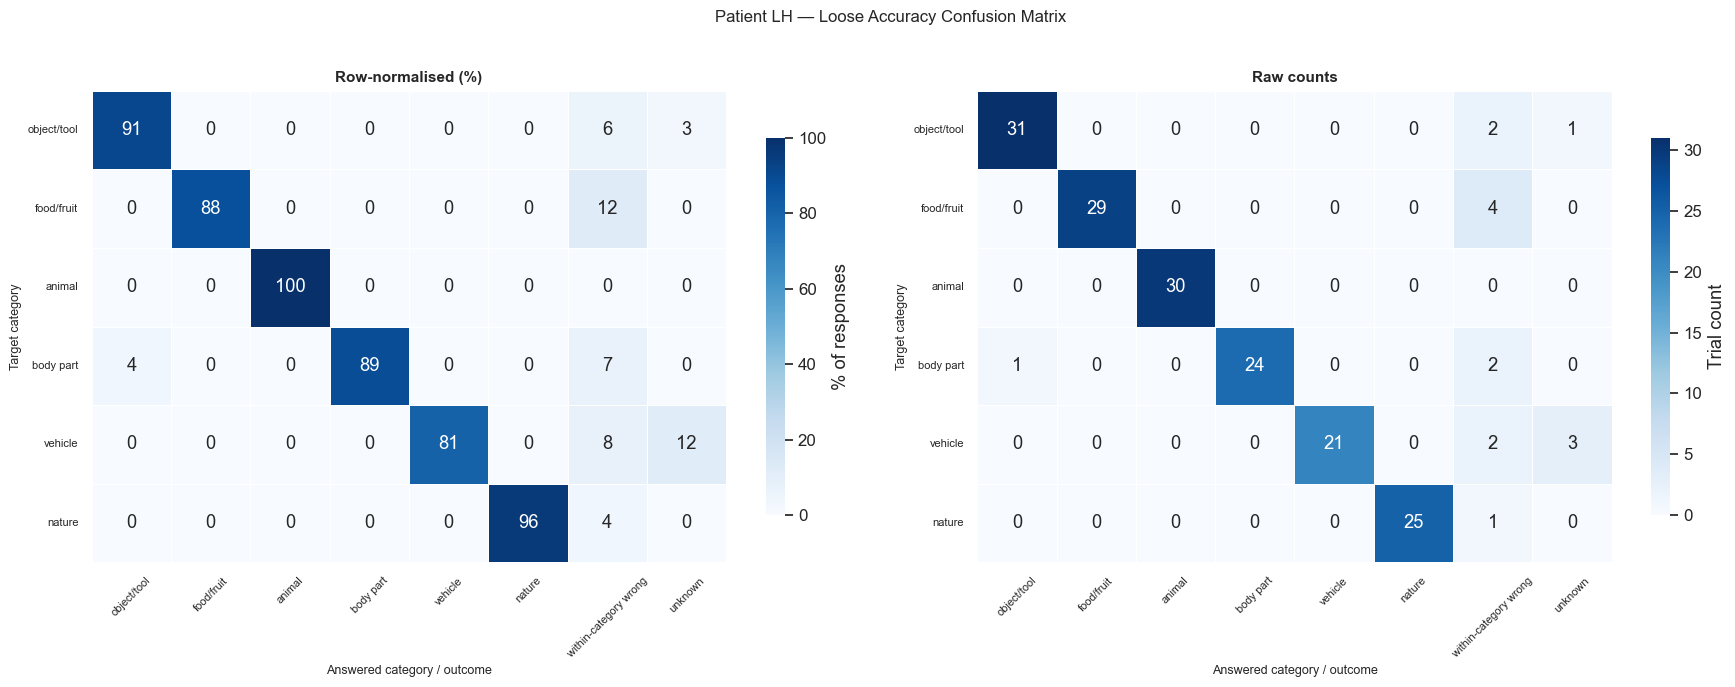

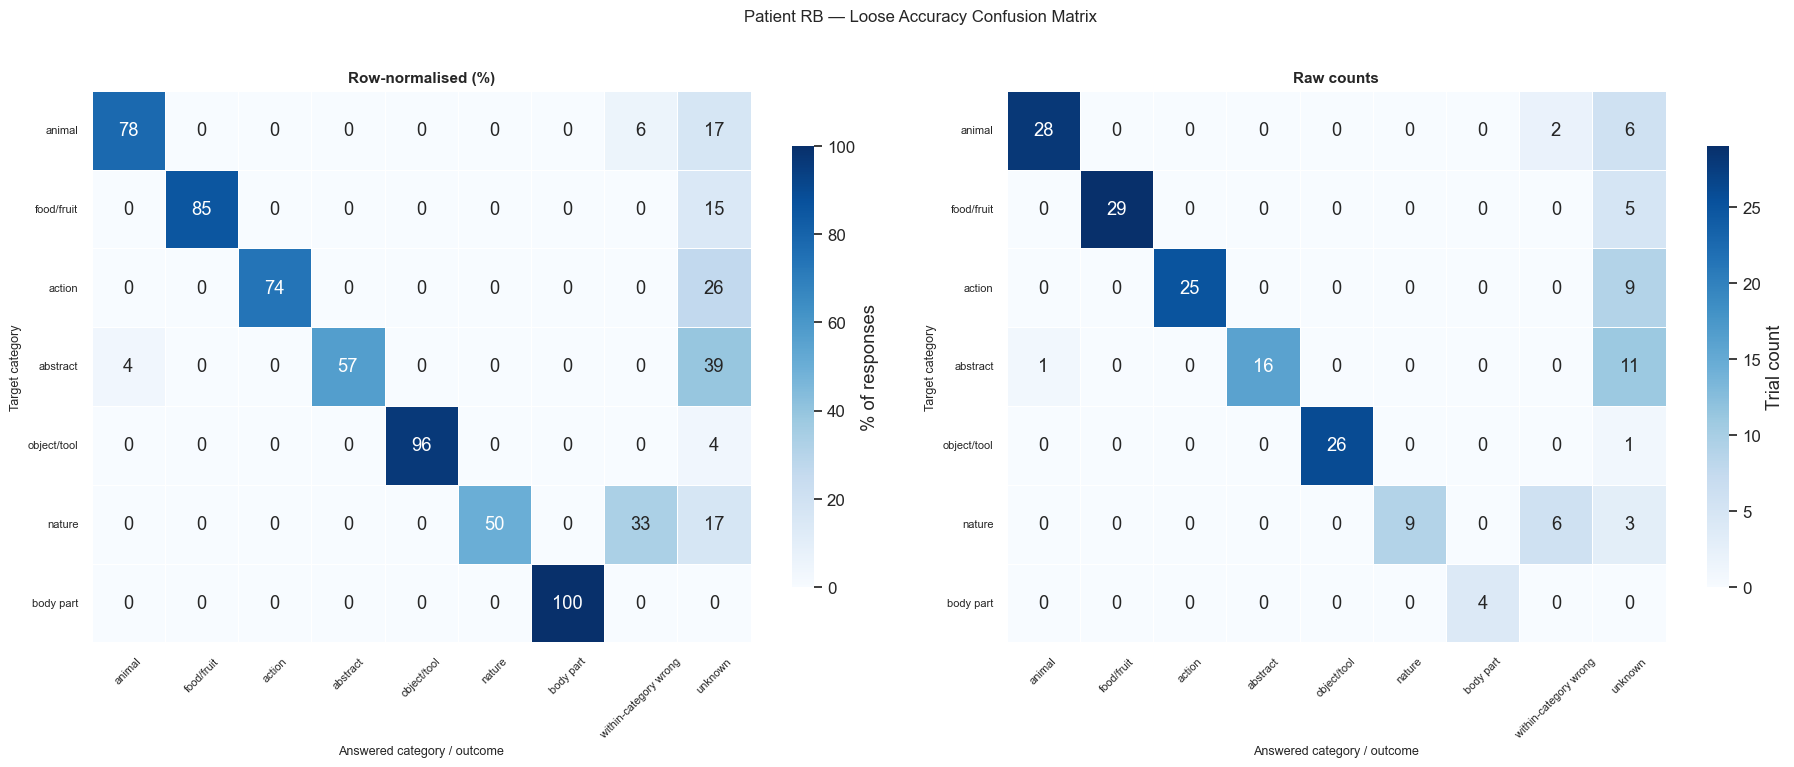

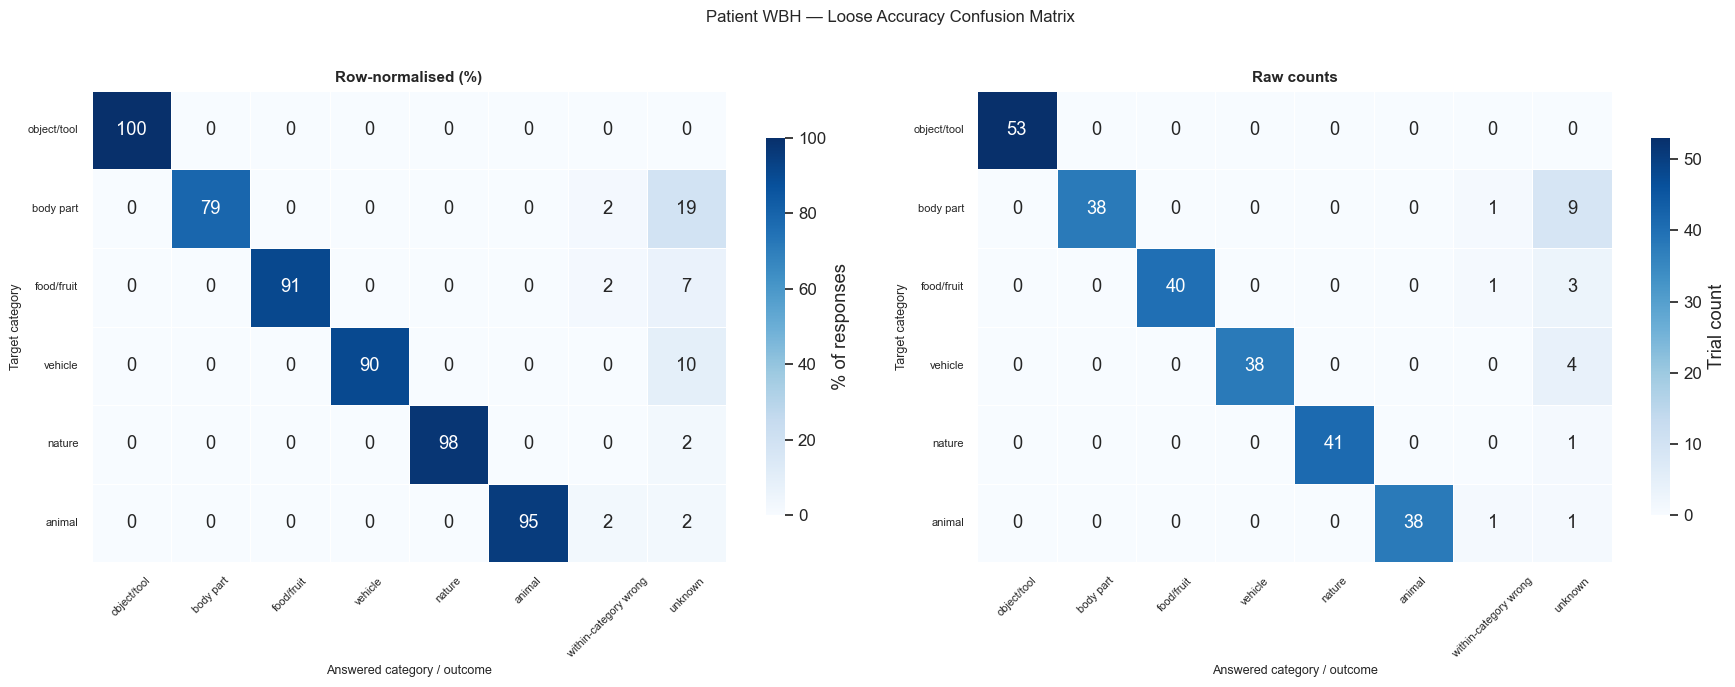

In [46]:

# ── Confusion matrices: loose accuracy by semantic category ───────────────
if 'beh_v' not in globals():
    raise RuntimeError('Run Cell 9 first to build beh_v.')

# Build a full word→category map from all patients' label files
_full_w2cat = {}
for _lbl in raw_labels.values():
    if _lbl is None or 'target_word' not in _lbl.columns:
        continue
    _cc = next((c for c in ('class', 'category', 'label') if c in _lbl.columns), None)
    if _cc:
        for _w, _c in zip(_lbl['target_word'].astype(str).str.strip().str.lower(),
                          _lbl[_cc].astype(str)):
            _full_w2cat[_w] = _c

def _build_cm(df_sub):
    """Return (counts_tab, normalised_tab, cat_ord) for a subset of beh_v."""
    d = df_sub.copy()
    d['target_cat']   = d['category']
    d['answered_cat'] = d['answered'].str.lower().map(_full_w2cat).fillna('unknown')
    d['ans_cat_l']    = np.where(d['correct_loose'], d['target_cat'], d['answered_cat'])

    known = d['target_cat'].value_counts().drop('unknown', errors='ignore').index.tolist()
    # Include 'unknown' whenever it appears as EITHER a target OR an answered category.
    # Without this, wrong answers whose answered word is not in _full_w2cat (= 'unknown')
    # would be silently dropped when reindexing columns, making the diagonal look 100%.
    has_unknown = ('unknown' in d['target_cat'].values) or ('unknown' in d['ans_cat_l'].values)
    cat_ord = known + (['unknown'] if has_unknown else [])

    tab = pd.crosstab(d['target_cat'], d['ans_cat_l'])
    tab = tab.reindex(index=cat_ord, columns=cat_ord, fill_value=0).fillna(0)
    norm = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return tab, norm, cat_ord

def _plot_cm_pair(tab, norm, cat_ord, suptitle):
    """Side-by-side: left = row-normalised %, right = raw counts."""
    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(cat_ord) * 0.8 + 2)))
    sns.heatmap(
        norm * 100, ax=axes[0], cmap='Blues', vmin=0, vmax=100,
        annot=True, fmt='.0f', linewidths=0.4, linecolor='white',
        xticklabels=norm.columns, yticklabels=norm.index,
        cbar_kws={'label': '% of responses', 'shrink': 0.8},
    )
    axes[0].set_title('Row-normalised (%)', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Answered category', fontsize=9)
    axes[0].set_ylabel('Target category', fontsize=9)
    axes[0].tick_params(axis='x', rotation=45, labelsize=8)
    axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

    sns.heatmap(
        tab, ax=axes[1], cmap='Blues',
        annot=True, fmt='.0f', linewidths=0.4, linecolor='white',
        xticklabels=tab.columns, yticklabels=tab.index,
        cbar_kws={'label': 'Trial count', 'shrink': 0.8},
    )
    axes[1].set_title('Raw counts', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Answered category', fontsize=9)
    axes[1].set_ylabel('Target category', fontsize=9)
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)
    axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

    fig.suptitle(suptitle, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

# ── All patients combined ─────────────────────────────────────────────────
tab_all, norm_all, cat_ord_all = _build_cm(beh_v)
_plot_cm_pair(tab_all, norm_all, cat_ord_all,
              'All patients — Loose Accuracy Confusion Matrix\n'
              '(diagonal = correct-category responses)')

_diag = pd.DataFrame({
    'loose_acc_%': (np.diag(norm_all.values) * 100).round(1),
    'n_correct':   np.diag(tab_all.values).astype(int),
    'n_total':     tab_all.sum(axis=1).astype(int),
}, index=cat_ord_all)
print('Diagonal accuracy per category (all patients):')
print(_diag.to_string())

# ── Per-patient ───────────────────────────────────────────────────────────
for pt in PATIENTS:
    sub = beh_v[beh_v['patient'] == pt]
    if len(sub) == 0:
        continue
    tab_pt, norm_pt, cat_ord_pt = _build_cm(sub)
    _plot_cm_pair(tab_pt, norm_pt, cat_ord_pt,
                  f'Patient {pt} — Loose Accuracy Confusion Matrix')


AA current category heatmap metric (correct_loose):
category
animal         100.0
body part       87.5
food/fruit      77.8
nature          88.9
object/tool    100.0
vehicle         88.9

AA matrix-style category metric (answered category == target category):
category
animal          77.8
body part      100.0
food/fruit     100.0
nature         100.0
object/tool    100.0
vehicle        100.0


In [34]:

# ── Wrong trials in the "unknown" category ────────────────────────────────
wrong_unknown = (
    beh_v[
        (beh_v['category'] == 'unknown') &
        (~beh_v['correct_loose'])
    ][['patient', 'trial_idx', 'target', 'answered']]
    .sort_values(['patient', 'target'])
    .reset_index(drop=True)
)

print(f'Wrong trials with target category == "unknown":  {len(wrong_unknown)}')
print()
print(wrong_unknown.to_string(index=False))


Wrong trials with target category == "unknown":  3

patient  trial_idx   target    answered
     DR         33 mountain   ski slope
     DR         35     pear  bell fruit
     DR         40    pizza pizza dough


In [19]:
# ── Audit loose matches (verbatim_match == False): grouped summary ─────────
if 'beh_v' not in globals():
    raise RuntimeError('Run Cell 9 first to build beh_v.')

def _safe_normalize_word(w):
    try:
        return _normalize(w)
    except Exception:
        s = str(w).strip().lower()
        for art in ('a ', 'an ', 'the '):
            if s.startswith(art):
                s = s[len(art):]
                break
        return ''.join(c for c in s if c.isalpha())

def _safe_synset_match(w1, w2):
    fn = globals().get('_share_synset', None)
    if callable(fn):
        try:
            return bool(fn(w1, w2))
        except Exception:
            return False
    return False

loose_audit = beh_v[['patient', 'trial_idx', 'target', 'answered']].copy()
loose_audit['target_transformed']   = loose_audit['target'].map(_safe_normalize_word)
loose_audit['answered_transformed'] = loose_audit['answered'].map(_safe_normalize_word)
loose_audit['verbatim_match']    = loose_audit['target'].str.lower().eq(loose_audit['answered'].str.lower())
loose_audit['transformed_match'] = loose_audit['target_transformed'].eq(loose_audit['answered_transformed'])
loose_audit['synset_match'] = [
    _safe_synset_match(t, a)
    for t, a in zip(loose_audit['target_transformed'], loose_audit['answered_transformed'])
]
loose_audit['is_loose'] = [
    _correct_loose(t, a, True)
    for t, a in zip(loose_audit['target'], loose_audit['answered'])
]
# Priority: verbatim > transformed_match > synset_match
loose_audit['loose_reason'] = np.select(
    [
        loose_audit['verbatim_match'],
        loose_audit['transformed_match'],
        loose_audit['synset_match'],
    ],
    ['verbatim', 'transformed_match', 'synset_match'],
    default='other',
)

loose_only = (
    loose_audit[loose_audit['is_loose'] & ~loose_audit['verbatim_match']]
    .sort_values(['loose_reason', 'target'])
    .reset_index(drop=True)
)

EXAMPLES_PER_GROUP = 5

print(f'Non-verbatim loose cases total: {len(loose_only)}')
print('=' * 70)

reason_descriptions = {
    'transformed_match': (
        'Transformed match  '
        '(article strip / lemmatisation makes target == answered)',
        ['target', 'answered', 'target_transformed', 'answered_transformed']
    ),
    'synset_match': (
        'Synset match  '
        '(WordNet noun synsets overlap — genuine synonyms/hypernyms)',
        ['target', 'answered', 'target_transformed', 'answered_transformed']
    ),
    'other': (
        'Other  (caught by _correct_loose but not by the above two checks)',
        ['target', 'answered', 'target_transformed', 'answered_transformed']
    ),
}

for reason, (desc, show_cols) in reason_descriptions.items():
    grp = loose_only[loose_only['loose_reason'] == reason]
    if len(grp) == 0:
        continue
    print(f'\n[{reason}]  n={len(grp)}')
    print(f'  {desc}')
    print()
    # Unique target↔answered pairs with patient count
    pair_counts = (
        grp.groupby(['target', 'answered', 'answered_transformed'])
        .agg(n_trials=('patient', 'count'), patients=('patient', lambda x: ', '.join(sorted(set(x)))))
        .reset_index()
        .sort_values('n_trials', ascending=False)
    )
    print(f'  Unique pairs: {len(pair_counts)}  |  Showing top {min(EXAMPLES_PER_GROUP, len(pair_counts))} by frequency:')
    print(pair_counts.head(EXAMPLES_PER_GROUP).to_string(index=False))

print()
print('=' * 70)
print('Full non-verbatim loose case list:')
print(loose_only[['patient','trial_idx','target','answered',
                   'target_transformed','answered_transformed','loose_reason']]
      .to_string(index=False))

Non-verbatim loose cases total: 176

[transformed_match]  n=159
  Transformed match  (article strip / lemmatisation makes target == answered)

  Unique pairs: 66  |  Showing top 5 by frequency:
target answered answered_transformed  n_trials    patients
 grape   grapes                grape         7 LH, RB, WBH
   leg     legs                  leg         6 AZ, LH, WBH
  can2      can                  can         5          RB
 miss1     miss                 miss         5          RB
  key2     keys                  key         5          RB

[synset_match]  n=17
  Synset match  (WordNet noun synsets overlap — genuine synonyms/hypernyms)

  Unique pairs: 5  |  Showing top 5 by frequency:
  target answered answered_transformed  n_trials    patients
    bike  bicycle              bicycle         8 AZ, DR, WBH
airplane    plane                plane         3     AZ, WBH
airplane  a plane                plane         2         WBH
    taxi      cab                  cab         2      AZ, D

In [66]:
# Invalid / no-response breakdown
inv = (beh[~beh['valid_response']]
       .groupby(['patient', 'answered'])
       .size()
       .reset_index(name='count')
       .sort_values(['patient', 'count'], ascending=[True, False]))
print('Invalid / no-response tokens per patient:')
print(inv.to_string(index=False))

Invalid / no-response tokens per patient:
Empty DataFrame
Columns: [patient, answered, count]
Index: []


---
## Section 2 — Per-word accuracy

In [20]:
word_acc = (
    beh_v
    .groupby(['patient', 'target'])['correct_loose']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'acc', 'sum': 'n_correct', 'count': 'n_trials'})
    .reset_index()
)

# Pivot: rows = target word, cols = patient
pivot = word_acc.pivot_table(index='target', columns='patient',
                              values='acc', aggfunc='mean')
pivot['mean_acc'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean_acc', ascending=True)
pivot_pct = (pivot * 100).round(1)

print(f'Unique target words: {len(pivot)}')

Unique target words: 110


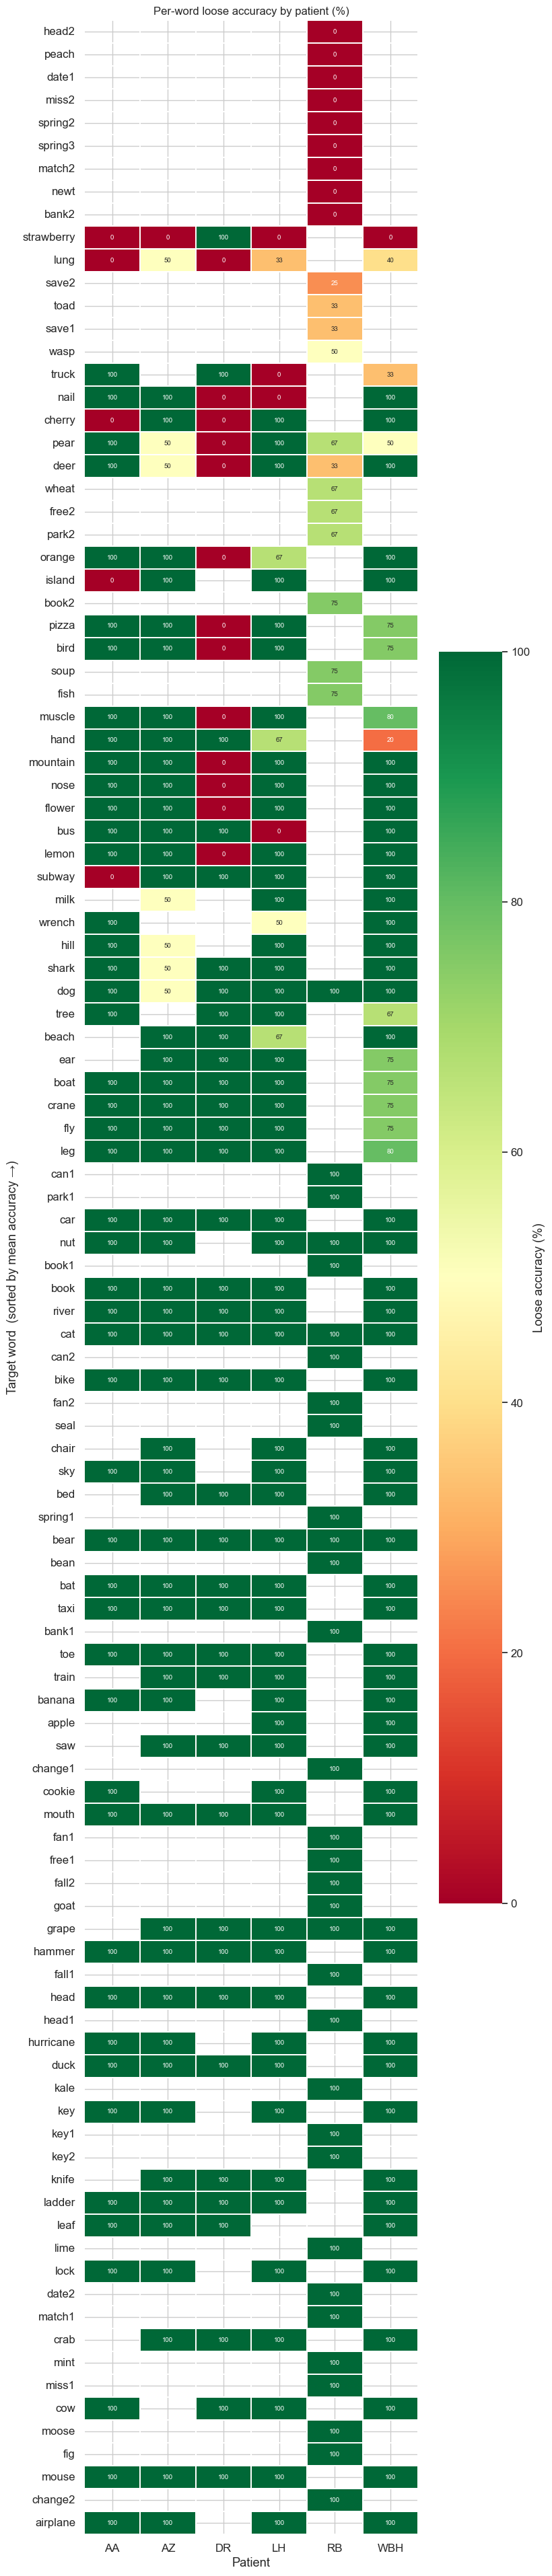

In [25]:
# ── Heatmap: words × patients ─────────────────────────────────────────────
heat_data = pivot_pct.drop(columns='mean_acc').fillna(np.nan)

n_words = len(heat_data)
n_pts   = len(heat_data.columns)
fig, ax = plt.subplots(figsize=(max(6, n_pts * 1.4), max(8, n_words * 0.35)))

sns.heatmap(
    heat_data,
    ax         = ax,
    cmap       = 'RdYlGn',
    vmin=0, vmax=100,
    linewidths = 0.3, linecolor='white',
    annot      = True, fmt='.0f', annot_kws={'size': 7},
    cbar_kws   = {'label': 'Loose accuracy (%)'},
)
ax.set_title('Per-word loose accuracy by patient (%)', fontsize=12)
ax.set_xlabel('Patient')
ax.set_ylabel('Target word  (sorted by mean accuracy →)')
plt.tight_layout()
plt.show()

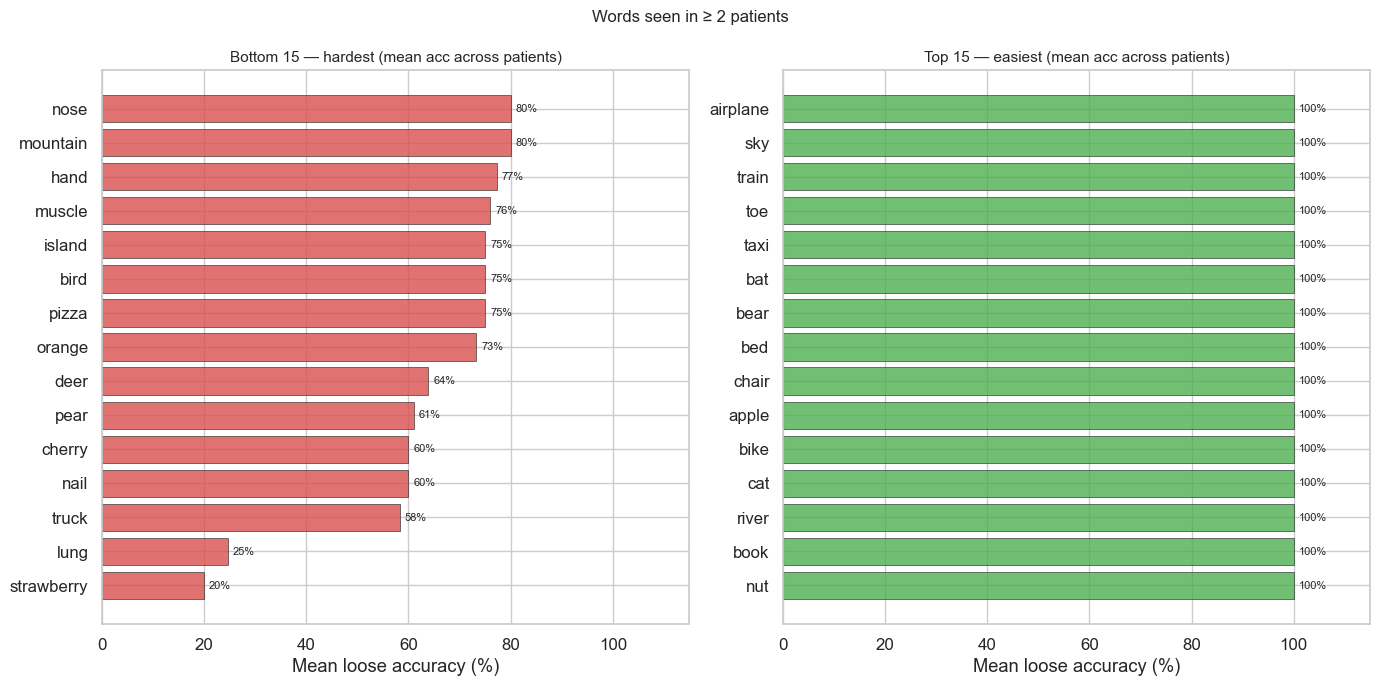

In [26]:
# ── Consistently easy / hard words (seen in ≥ 2 patients) ────────────────
n_pts_per_word = heat_data.notna().sum(axis=1)
multi_words    = n_pts_per_word[n_pts_per_word >= 2].index
pivot_multi    = pivot_pct.loc[multi_words].sort_values('mean_acc')

n_show = min(15, len(pivot_multi))
hardest = pivot_multi.head(n_show)
easiest = pivot_multi.tail(n_show)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, n_show * 0.4 + 1)))
for ax, data, title, color in zip(
    axes,
    [hardest, easiest],
    [f'Bottom {n_show} — hardest (mean acc across patients)',
     f'Top {n_show} — easiest (mean acc across patients)'],
    ['#d94f4f', '#4caf50'],
):
    ax.barh(data.index, data['mean_acc'], color=color, alpha=0.8,
            edgecolor='k', linewidth=0.5)
    ax.set_xlim(0, 115)
    ax.set_xlabel('Mean loose accuracy (%)')
    ax.set_title(title, fontsize=11)
    for i, (word, row_) in enumerate(data.iterrows()):
        ax.text(row_['mean_acc'] + 1, i, f"{row_['mean_acc']:.0f}%",
                va='center', fontsize=8)

fig.suptitle('Words seen in ≥ 2 patients', fontsize=12)
plt.tight_layout()
plt.show()

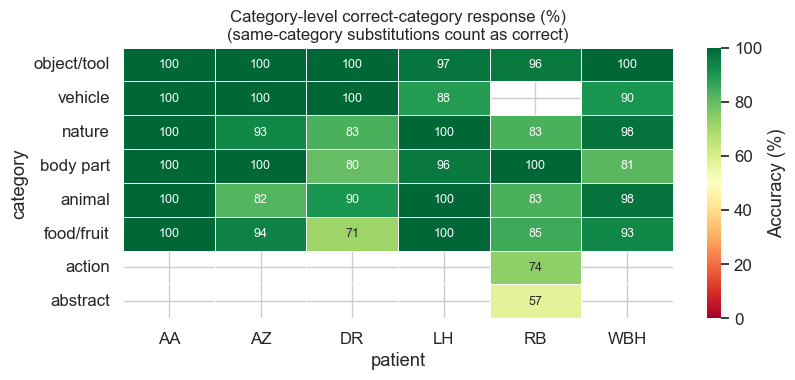

In [48]:
# ── Category-level accuracy ───────────────────────────────────────────────
cat_data = beh_v[beh_v['category'] != 'unknown'].copy()
if len(cat_data) > 0:
    _cat_map = {}
    for _lbl in raw_labels.values():
        if _lbl is None or 'target_word' not in _lbl.columns:
            continue
        _cc = next((c for c in ('class', 'category', 'label') if c in _lbl.columns), None)
        if _cc:
            for _w, _c in zip(_lbl['target_word'].astype(str).str.strip().str.lower(),
                              _lbl[_cc].astype(str)):
                _cat_map[_w] = _c

    cat_data['answered_cat'] = cat_data['answered'].str.lower().map(_cat_map).fillna('unknown')
    cat_data['correct_category_response'] = (
        cat_data['correct_loose'] |
        cat_data['answered_cat'].eq(cat_data['category'])
    )

    cat_acc = (
        cat_data
        .groupby(['patient', 'category'])['correct_category_response']
        .mean().mul(100).reset_index(name='acc_pct')
    )
    cat_pivot = cat_acc.pivot_table(index='category', columns='patient',
                                    values='acc_pct', aggfunc='mean')
    cat_pivot['mean'] = cat_pivot.mean(axis=1)
    cat_pivot = cat_pivot.sort_values('mean', ascending=False)

    fig, ax = plt.subplots(figsize=(max(7, n_pts * 1.4), max(4, len(cat_pivot) * 0.5)))
    sns.heatmap(
        cat_pivot.drop(columns='mean').fillna(np.nan),
        ax=ax, cmap='RdYlGn', vmin=0, vmax=100,
        annot=True, fmt='.0f', annot_kws={'size': 9},
        linewidths=0.4, linecolor='white',
        cbar_kws={'label': 'Accuracy (%)'},
    )
    ax.set_title('Category-level correct-category response (%)\n'
                 '(same-category substitutions count as correct)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No category information available (labels pkl missing or no class/category column).')

In [28]:
# ── Most common wrong answers ─────────────────────────────────────────────
wrong_counts = (
    beh_v[~beh_v['correct_loose']]
    .groupby(['target', 'answered'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print('Top 25 most common wrong answers (across all patients):')
print(wrong_counts.head(25).to_string(index=False))

Top 25 most common wrong answers (across all patients):
    target   answered  count
strawberry     cherry      6
      lung       nose      4
    match2    fashion      4
     date1    january      4
      nail     hammer      3
     bank2       hill      3
      hand    fingers      3
     truck       semi      3
   spring2      river      3
      deer      moose      2
     head2    forward      2
     save2     saving      2
      lung      mouth      2
     peach      mango      2
     miss2       lady      2
    cherry strawberry      2
       bus       taxi      2
     truck  semitruck      2
      wasp        bee      2
     pizza    lasagna      1
      pear bell fruit      1
     park2      field      1
      pear  chocolate      1
    orange       lime      1
    orange     banana      1


---
## Section 3 — Wrong but semantically close answers

Uses **GloVe 840B 300d** (available in the project via `torchtext`) to compute cosine similarity between target and answered word embeddings.  
A wrong answer with high cosine similarity is a **close miss** — semantically correct but verbatim wrong (e.g. target=`dog`, answered=`puppy`).

In [29]:
import torchtext
try:
    torchtext.disable_torchtext_deprecation_warning()
except AttributeError:
    pass
from torchtext.vocab import GloVe

print('Loading GloVe 840B 300d  (may take ~1 min on first run) …')
glove = GloVe(name='840B', dim=300)
print(f'GloVe loaded.  Vocab size: {len(glove.stoi):,}')

Loading GloVe 840B 300d  (may take ~1 min on first run) …
GloVe loaded.  Vocab size: 2,196,016


In [30]:
def get_glove(word):
    """Return unit-normed GloVe vector (float32 numpy), or None if OOV."""
    w = str(word).lower().strip()
    if w not in glove.stoi:
        return None
    v = glove[w].numpy().astype(np.float64)
    n = np.linalg.norm(v)
    return (v / n) if n > 0 else None

def cosine_sim_words(w1, w2):
    v1, v2 = get_glove(w1), get_glove(w2)
    if v1 is None or v2 is None:
        return np.nan
    return float(np.dot(v1, v2))

# Cache to avoid repeated lookups
all_words = set(beh_v['target'].tolist() + beh_v['answered'].tolist())
glove_cache = {w: get_glove(w) for w in all_words}

print(f'Words: {len(all_words)}  |  OOV: {sum(v is None for v in glove_cache.values())}')

print('Computing GloVe similarities …')
beh_v = beh_v.copy()
beh_v['glove_sim'] = [
    cosine_sim_words(row.target, row.answered)
    for _, row in beh_v.iterrows()
]

n_nan = beh_v['glove_sim'].isna().sum()
print(f'OOV (NaN sims):  {n_nan}')
print(f'Correct mean:    {beh_v.loc[beh_v.correct_loose,   "glove_sim"].mean():.3f}')
print(f'Wrong mean:      {beh_v.loc[~beh_v.correct_loose,  "glove_sim"].mean():.3f}')

Words: 218  |  OOV: 54
Computing GloVe similarities …
OOV (NaN sims):  98
Correct mean:    0.905
Wrong mean:      0.432


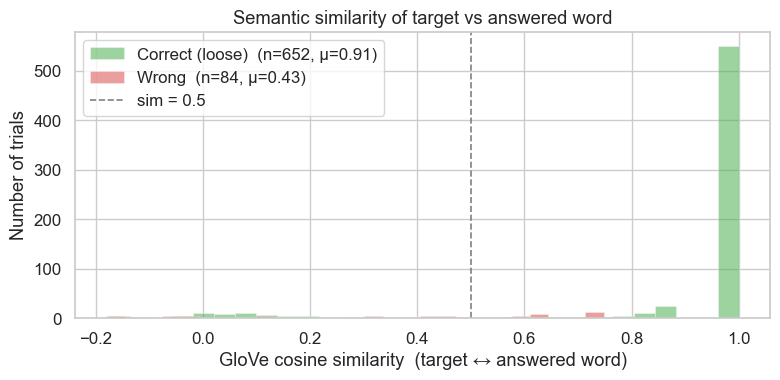

In [31]:
# ── Distribution: correct vs wrong ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, mask in [
    ('Correct (loose)',  '#4caf50',  beh_v['correct_loose']),
    ('Wrong',             '#d94f4f', ~beh_v['correct_loose']),
]:
    vals = beh_v.loc[mask, 'glove_sim'].dropna()
    ax.hist(vals, bins=30, alpha=0.55, color=color, edgecolor='w', linewidth=0.4,
            label=f'{label}  (n={len(vals)}, μ={vals.mean():.2f})')

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.2, label='sim = 0.5')
ax.set_xlabel('GloVe cosine similarity  (target ↔ answered word)')
ax.set_ylabel('Number of trials')
ax.set_title('Semantic similarity of target vs answered word')
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
# ── Close misses: wrong verbatim but semantically similar ─────────────────
SIM_THRESHOLD = 0.5

close_misses = (
    beh_v[
        (~beh_v['correct_loose']) &
        (beh_v['glove_sim'] >= SIM_THRESHOLD)
    ]
    .groupby(['target', 'answered', 'category'])
    .agg(
        count    = ('patient', 'count'),
        patients = ('patient', lambda x: ', '.join(sorted(set(x)))),
        sim      = ('glove_sim', 'mean'),
    )
    .reset_index()
    .sort_values('sim', ascending=False)
)

print(f'Close misses (sim ≥ {SIM_THRESHOLD}):  {len(close_misses)} unique target↔answer pairs')
print()
print(close_misses.head(30).to_string(index=False))

Close misses (sim ≥ 0.5):  32 unique target↔answer pairs

    target    answered    category  count        patients      sim
      deer         elk      animal      1              DR 0.851064
      deer       moose      animal      2              RB 0.808838
     lemon        lime  food/fruit      1              DR 0.778827
    wrench screwdriver object/tool      1              LH 0.774440
      milk       dairy  food/fruit      1              AZ 0.749787
      pear       peach  food/fruit      1              AZ 0.738206
       bus        taxi     vehicle      2              LH 0.725246
      boat       canoe     vehicle      1             WBH 0.723343
    orange        lime  food/fruit      1              DR 0.719021
    cherry  strawberry  food/fruit      2          AA, DR 0.714353
strawberry      cherry  food/fruit      6 AA, AZ, LH, WBH 0.714353
     peach       mango  food/fruit      2              RB 0.688988
     pizza     lasagna  food/fruit      1             WBH 0.668181
stra

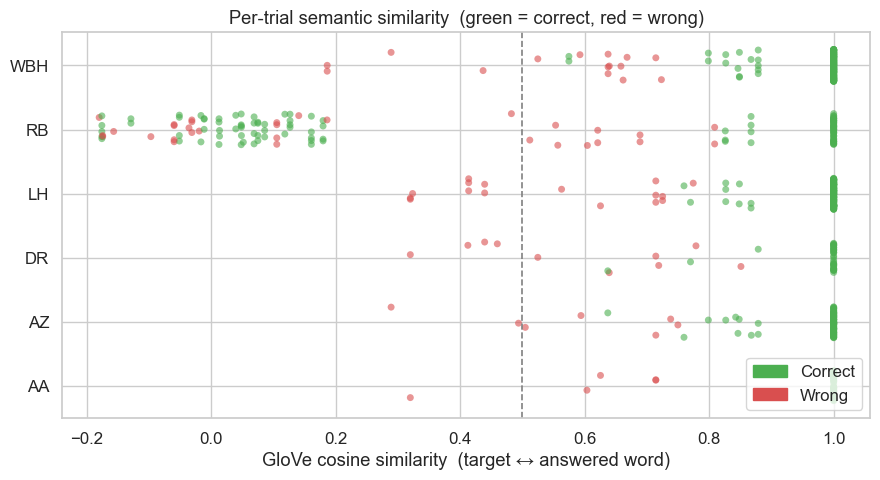

In [89]:
# ── Per-trial scatter: x = GloVe sim, y = patient (jittered) ─────────────
fig, ax = plt.subplots(figsize=(9, 5))
rng = np.random.default_rng(42)

for pt in PATIENTS:
    sub = beh_v[(beh_v.patient == pt) & beh_v['glove_sim'].notna()]
    if len(sub) == 0:
        continue
    y_pos   = PATIENTS.index(pt)
    jitter  = rng.uniform(-0.25, 0.25, len(sub))
    colors  = ['#4caf50' if c else '#d94f4f' for c in sub['correct_loose']]
    ax.scatter(sub['glove_sim'], y_pos + jitter,
               c=colors, alpha=0.6, s=25, linewidths=0)

ax.set_yticks(range(len(PATIENTS)))
ax.set_yticklabels(PATIENTS)
ax.axvline(SIM_THRESHOLD, color='gray', linestyle='--', linewidth=1.2,
           label=f'sim = {SIM_THRESHOLD}')
ax.set_xlabel('GloVe cosine similarity  (target ↔ answered word)')
ax.set_title('Per-trial semantic similarity  (green = correct, red = wrong)')
handles = [
    mpatches.Patch(color='#4caf50', label='Correct'),
    mpatches.Patch(color='#d94f4f', label='Wrong'),
]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

---
## Section 4 — Reaction time

**RT** = `voice_onset − go_cue_onset`  
- **Positive** → patient responded *after* the go cue (normal)  
- **Negative** → patient started speaking *before* the go cue (anticipatory / ignores cue)

Before interpreting go-cue RT, verify that the go cue occurs after the auditory stimulus ends.

In [50]:
rt_all = beh[beh['rt_from_go'].notna() & beh['valid_response']].copy()
rt_all['go_before_stim_on'] = rt_all['go_cue'] < rt_all['stim_onset']
rt_all['go_before_stim_off'] = rt_all['go_cue'] < rt_all['stim_offset']
rt_all['voice_before_stim_off'] = rt_all['voice_onset'] < rt_all['stim_offset']

timing_qc = rt_all.groupby('patient').agg(
    n_trials=('trial_idx', 'count'),
    pct_go_before_stim_on=('go_before_stim_on', 'mean'),
    pct_go_before_stim_off=('go_before_stim_off', 'mean'),
    pct_voice_before_stim_off=('voice_before_stim_off', 'mean'),
    median_go_minus_stim_off=('gap_stim_to_go', 'median'),
    min_go_minus_stim_off=('gap_stim_to_go', 'min'),
    max_go_minus_stim_off=('gap_stim_to_go', 'max'),
)
timing_qc[['pct_go_before_stim_on', 'pct_go_before_stim_off', 'pct_voice_before_stim_off']] *= 100
timing_qc = timing_qc.round(3)

print('Cue-order QC before computing go-cue RT:')
print(timing_qc.to_string())
print()

timing_issue_patients = timing_qc.index[timing_qc['pct_go_before_stim_off'] > 5].tolist()
if timing_issue_patients:
    print('Patients with non-comparable go-cue timing (>5% of trials have go cue before stimulus offset):')
    print(', '.join(timing_issue_patients))
    print()

rt = rt_all[~rt_all['go_before_stim_off']].copy()
rt_flagged = rt[rt['patient'].isin(timing_issue_patients)].copy()
rt = rt[~rt['patient'].isin(timing_issue_patients)].copy()

rt_summary = (
    rt.groupby('patient')['rt_from_go']
    .agg(
        n='count',
        mean_RT='mean',
        med_RT='median',
        std_RT='std',
        pct_before_go=lambda x: (x < 0).mean() * 100,
    )
    .round(3)
)
print('Reaction time stats (seconds from go cue) for patients/trials with valid cue ordering:')
print(rt_summary.to_string())
print()
print(f'Included trials after cue-order filtering: {len(rt)}/{len(rt_all)} valid-response trials')
if timing_issue_patients:
    print('Excluded patients from go-cue RT comparisons:', ', '.join(timing_issue_patients))
    print(f'Salvageable post-stimulus go-cue trials inside excluded patients: {len(rt_flagged)}')
print('Use rt_from_stim_end for cross-patient timing comparisons when cue timing is inconsistent.')

Cue-order QC before computing go-cue RT:
         n_trials  pct_go_before_stim_on  pct_go_before_stim_off  pct_voice_before_stim_off  median_go_minus_stim_off  min_go_minus_stim_off  max_go_minus_stim_off
patient                                                                                                                                                            
AA             53                  0.000                   0.000                       0.00                     3.480                  0.200                  6.050
AZ            104                  0.000                   0.000                       0.00                     3.523                  0.519                  5.888
DR             51                  0.000                   0.000                       0.00                     3.135                  0.347                  5.888
LH            176                  0.000                   0.000                       0.00                     3.600                  0.20

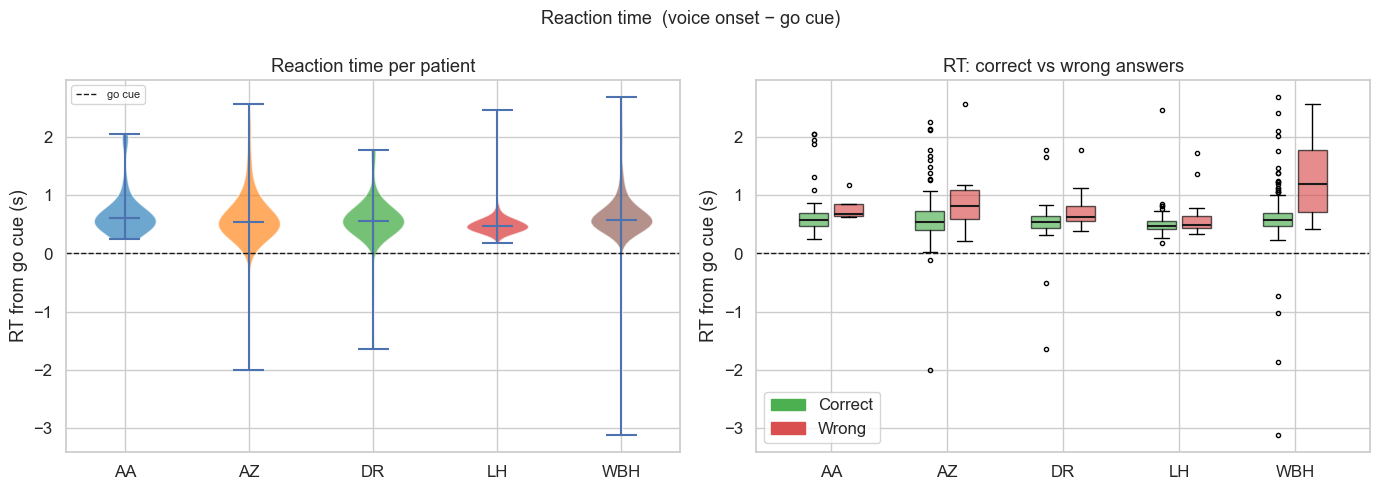

In [51]:
# ── Violin plot of RT per patient ─────────────────────────────────────────
pts_rt = [p for p in PATIENTS if p in rt['patient'].values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall RT violin per patient
ax = axes[0]
data_violin = [rt.loc[rt.patient == p, 'rt_from_go'].values for p in pts_rt]
parts = ax.violinplot(data_violin, positions=range(len(pts_rt)),
                      showmedians=True, showextrema=True)
for i, (pc, pt) in enumerate(zip(parts['bodies'], pts_rt)):
    pc.set_facecolor(PAL[pt])
    pc.set_alpha(0.65)
ax.set_xticks(range(len(pts_rt)))
ax.set_xticklabels(pts_rt)
ax.axhline(0, color='k', linestyle='--', linewidth=1, label='go cue')
ax.set_ylabel('RT from go cue (s)')
ax.set_title('Reaction time per patient')
ax.legend(fontsize=8)

# Right: box plot split by correct / wrong
ax = axes[1]
x_pos   = {p: i for i, p in enumerate(pts_rt)}
offsets = {True: -0.15, False: 0.15}
bx_colors = {True: '#4caf50', False: '#d94f4f'}
for correct in [True, False]:
    sub_c = rt[rt['correct_loose'] == correct]
    for pt in pts_rt:
        vals = sub_c.loc[sub_c.patient == pt, 'rt_from_go'].values
        if len(vals) < 2:
            continue
        ax.boxplot(
            vals,
            positions   = [x_pos[pt] + offsets[correct]],
            widths      = 0.25,
            patch_artist= True,
            medianprops = {'color': 'k', 'linewidth': 1.5},
            boxprops    = {'facecolor': bx_colors[correct], 'alpha': 0.65},
            whiskerprops= {'linewidth': 1},
            flierprops  = {'markersize': 3},
        )

ax.set_xticks(range(len(pts_rt)))
ax.set_xticklabels(pts_rt)
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_ylabel('RT from go cue (s)')
ax.set_title('RT: correct vs wrong answers')
ax.legend(handles=[
    mpatches.Patch(color='#4caf50', label='Correct'),
    mpatches.Patch(color='#d94f4f', label='Wrong'),
])

fig.suptitle('Reaction time  (voice onset − go cue)', fontsize=13)
plt.tight_layout()
plt.show()

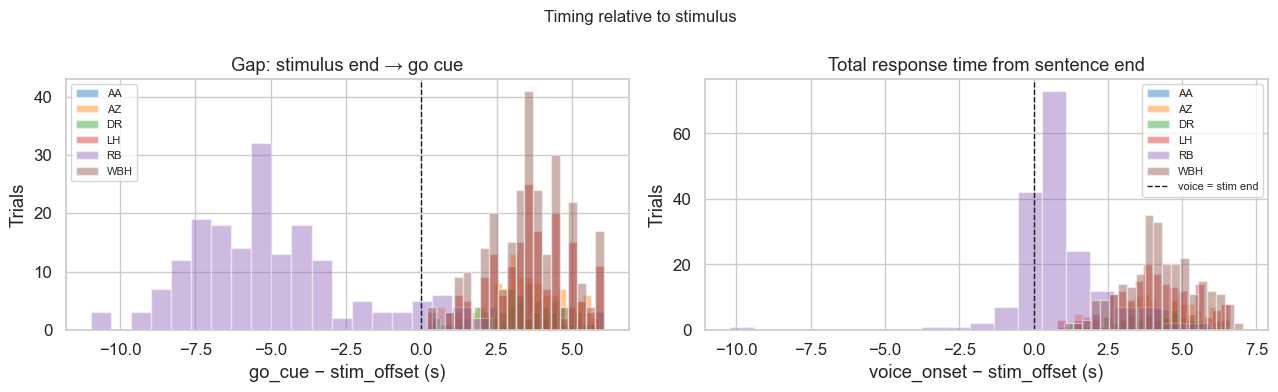

Gap (go_cue − stim_offset) stats per patient:
          mean  median    std     min    max
patient                                     
AA       3.502   3.480  1.329   0.200  6.050
AZ       3.532   3.523  1.228   0.519  5.888
DR       3.260   3.135  1.312   0.347  5.888
LH       3.598   3.600  1.314   0.200  6.050
RB      -4.999  -5.310  2.705 -10.960  2.340
WBH      3.612   3.520  1.296   0.200  6.050


In [79]:
# ── Gap: go cue relative to sentence end ─────────────────────────────────
# gap_stim_to_go = go_cue − stim_offset
# positive → go cue comes AFTER sentence ends (normal design)
# negative → go cue while audio still playing
gap = beh[beh['gap_stim_to_go'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for pt in PATIENTS:
    s = gap.loc[gap.patient == pt, 'gap_stim_to_go'].dropna()
    if len(s):
        ax.hist(s, bins=20, alpha=0.45, label=pt, color=PAL[pt], edgecolor='w')
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('go_cue − stim_offset (s)')
ax.set_ylabel('Trials')
ax.set_title('Gap: stimulus end → go cue')
ax.legend(fontsize=8)

# ── Total response time from sentence end ────────────────────────────────
rt2 = beh[beh['rt_from_stim_end'].notna() & beh['valid_response']].copy()
ax = axes[1]
for pt in PATIENTS:
    s = rt2.loc[rt2.patient == pt, 'rt_from_stim_end'].dropna()
    if len(s):
        ax.hist(s, bins=20, alpha=0.45, label=pt, color=PAL[pt], edgecolor='w')
ax.axvline(0, color='k', linestyle='--', linewidth=1, label='voice = stim end')
ax.set_xlabel('voice_onset − stim_offset (s)')
ax.set_ylabel('Trials')
ax.set_title('Total response time from sentence end')
ax.legend(fontsize=8)

fig.suptitle('Timing relative to stimulus', fontsize=12)
plt.tight_layout()
plt.show()

print('Gap (go_cue − stim_offset) stats per patient:')
print(gap.groupby('patient')['gap_stim_to_go']
      .agg(['mean','median','std','min','max']).round(3).to_string())

---
## Section 5 — Stimulus characteristics

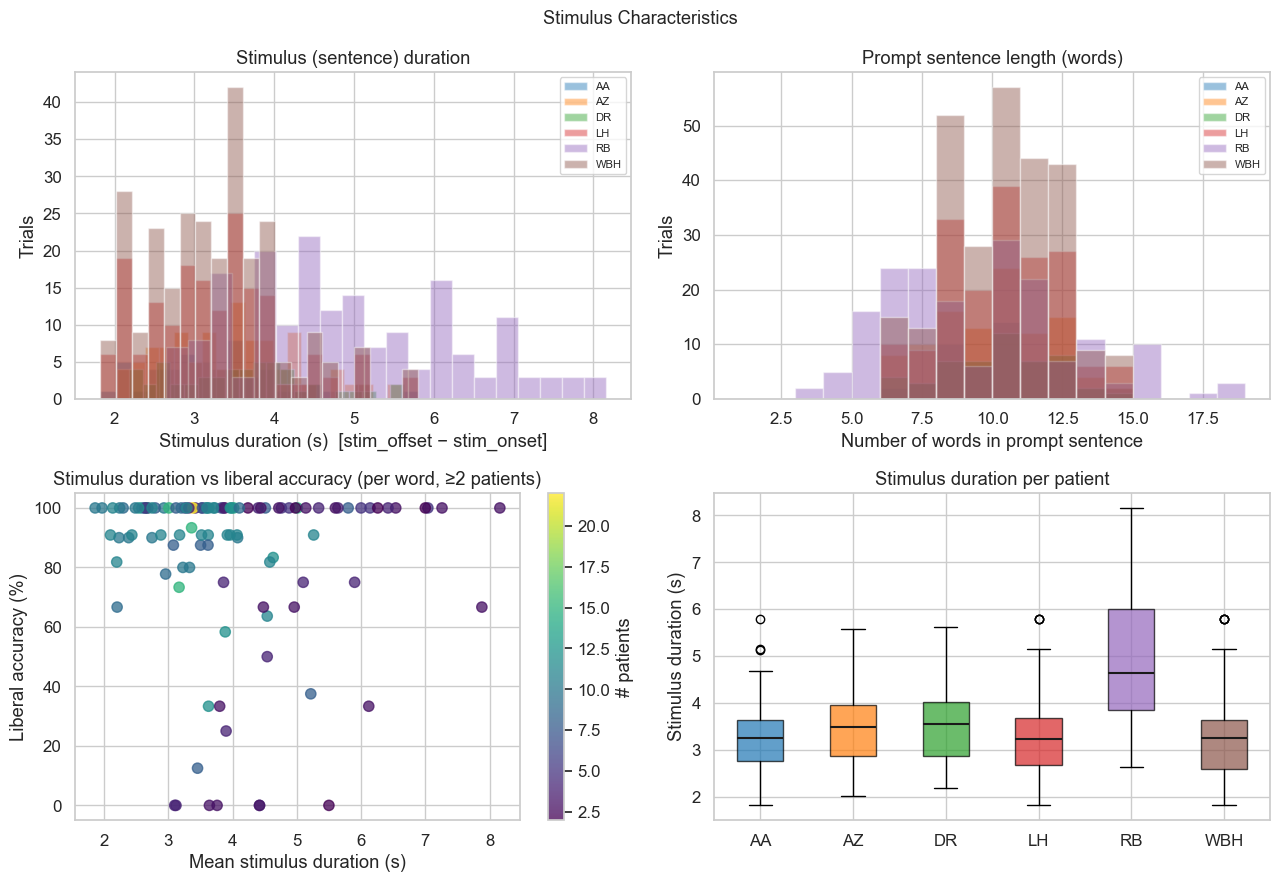


Per-patient stimulus duration stats (s):
          mean  median    std    min    max
patient                                    
AA       3.305   3.260  0.840  1.820  5.800
AZ       3.459   3.488  0.818  2.028  5.589
DR       3.552   3.564  0.846  2.180  5.622
LH       3.251   3.230  0.843  1.820  5.800
RB       4.914   4.640  1.372  2.640  8.160
WBH      3.244   3.260  0.815  1.820  5.800


In [80]:
stim = beh[beh['stim_dur'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Stimulus duration distribution
ax = axes[0, 0]
for pt in PATIENTS:
    s = stim.loc[stim.patient == pt, 'stim_dur'].dropna()
    if len(s):
        ax.hist(s, bins=20, alpha=0.45, label=pt, color=PAL[pt], edgecolor='w')
ax.set_xlabel('Stimulus duration (s)  [stim_offset − stim_onset]')
ax.set_ylabel('Trials')
ax.set_title('Stimulus (sentence) duration')
ax.legend(fontsize=8)

# 2. Prompt word count
ax = axes[0, 1]
for pt in PATIENTS:
    s = beh.loc[beh.patient == pt, 'n_words_prompt']
    if len(s):
        ax.hist(s, bins=range(1, 20), alpha=0.45, label=pt, color=PAL[pt], edgecolor='w')
ax.set_xlabel('Number of words in prompt sentence')
ax.set_ylabel('Trials')
ax.set_title('Prompt sentence length (words)')
ax.legend(fontsize=8)

# 3. Stim duration vs accuracy per word
ax = axes[1, 0]
wstim = (
    stim[stim['valid_response']]
    .groupby('target')
    .agg(mean_dur=('stim_dur', 'mean'),
         acc=('correct_loose', 'mean'),
         n=('patient', 'count'))
    .reset_index()
)
wstim = wstim[wstim['n'] >= 2]
sc = ax.scatter(wstim['mean_dur'], wstim['acc'] * 100,
                c=wstim['n'], cmap='viridis', s=55, alpha=0.75)
plt.colorbar(sc, ax=ax, label='# patients')
ax.set_xlabel('Mean stimulus duration (s)')
ax.set_ylabel('Loose accuracy (%)')
ax.set_title('Stimulus duration vs loose accuracy (per word, ≥2 patients)')

# 4. Box plot: stim duration per patient
ax = axes[1, 1]
pts_stim = [p for p in PATIENTS if p in stim['patient'].values]
data_bp = [stim.loc[stim.patient == p, 'stim_dur'].dropna().values for p in pts_stim]
bp = ax.boxplot(data_bp, patch_artist=True,
                medianprops={'color': 'k', 'linewidth': 1.5})
for patch, pt in zip(bp['boxes'], pts_stim):
    patch.set_facecolor(PAL[pt])
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(pts_stim) + 1))
ax.set_xticklabels(pts_stim)
ax.set_ylabel('Stimulus duration (s)')
ax.set_title('Stimulus duration per patient')

fig.suptitle('Stimulus Characteristics', fontsize=13)
plt.tight_layout()
plt.show()

print('\nPer-patient stimulus duration stats (s):')
print(stim.groupby('patient')['stim_dur']
      .agg(['mean','median','std','min','max']).round(3).to_string())

---
## Section 6 — Embedding comparison

Three representations are compared:
- **Target word** — GloVe single-word embedding
- **Answered word** — GloVe single-word embedding
- **Prompt sentence** — sentence-transformer (`all-MiniLM-L6-v2`) if installed; otherwise mean-GloVe

Questions:
1. How close is the prompt sentence to the target word in embedding space?
2. For wrong answers, is the answered word closer to the prompt than the target?
3. Do prompt sentence embeddings cluster by semantic category (PCA / t-SNE)?

In [81]:
# ── Load sentence embedding model ─────────────────────────────────────────
USE_SBERT   = False
sbert_model = None

try:
    from sentence_transformers import SentenceTransformer
    print('Loading sentence-transformers all-MiniLM-L6-v2 …')
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
    USE_SBERT   = True
    print('sentence-transformers model ready.')
except ImportError:
    print('sentence-transformers not installed.')
    print('Install with:  pip install sentence-transformers')
    print('Falling back to mean-GloVe sentence embeddings.')

def embed_sentence(text):
    """Embed a sentence.  Uses SBERT if available, otherwise mean GloVe."""
    if USE_SBERT:
        return sbert_model.encode(
            [text], convert_to_numpy=True, show_progress_bar=False
        )[0].astype(np.float32)
    # Fallback: mean of unit-normed GloVe vectors
    words = str(text).lower().split()
    vecs  = [(glove_cache[w] if w in glove_cache and glove_cache[w] is not None else get_glove(w)) for w in words]
    vecs  = [v for v in vecs if v is not None]
    if not vecs:
        return None
    return np.mean(vecs, axis=0).astype(np.float32)

EMB_MODE = 'SBERT all-MiniLM-L6-v2' if USE_SBERT else 'mean GloVe 840B'
print(f'Embedding mode: {EMB_MODE}')

sentence-transformers not installed.
Install with:  pip install sentence-transformers
Falling back to mean-GloVe sentence embeddings.
Embedding mode: mean GloVe 840B


In [82]:
# ── Compute and cache all sentence embeddings ─────────────────────────────
unique_sents = beh_v['prompt_sentence'].unique().tolist()
print(f'Unique prompt sentences: {len(unique_sents)}')
print('Computing sentence embeddings …')

sent_cache = {}
for s in unique_sents:
    if s and s not in sent_cache:
        sent_cache[s] = embed_sentence(s)

n_ok = sum(v is not None for v in sent_cache.values())
print(f'Sentences embedded: {n_ok}/{len(unique_sents)}')

Unique prompt sentences: 134
Computing sentence embeddings …
Sentences embedded: 134/134


In [83]:
# ── Per-trial: sim(prompt, target) and sim(prompt, answered) ─────────────
def safe_cosine(v1, v2):
    if v1 is None or v2 is None:
        return np.nan
    a = np.asarray(v1, dtype=np.float64).ravel()
    b = np.asarray(v2, dtype=np.float64).ravel()
    if a.shape != b.shape:
        return np.nan
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a / na, b / nb))

sims_pt, sims_pa, sims_ta = [], [], []
for _, row in beh_v.iterrows():
    vt = glove_cache.get(row.target)
    va = glove_cache.get(row.answered)
    vs = sent_cache.get(row.prompt_sentence)
    # sim(prompt, *) is only meaningful in the SAME embedding space;
    # mean-GloVe sentence is in GloVe space, so directly comparable to GloVe words.
    # SBERT and GloVe are in different spaces, so we skip cross-space comparisons.
    if USE_SBERT:
        sims_pt.append(np.nan)  # cross-space — not interpretable
        sims_pa.append(np.nan)
    else:
        sims_pt.append(safe_cosine(vs, vt))
        sims_pa.append(safe_cosine(vs, va))
    sims_ta.append(safe_cosine(vt, va))  # both GloVe — always valid

beh_v = beh_v.copy()
beh_v['sim_target_answered'] = sims_ta
beh_v['sim_prompt_target']   = sims_pt
beh_v['sim_prompt_answered'] = sims_pa

print('Mean similarities:')
for col in ['sim_target_answered', 'sim_prompt_target', 'sim_prompt_answered']:
    m = beh_v[col].mean()
    print(f'  {col}: {m:.3f}')

Mean similarities:
  sim_target_answered: 0.851
  sim_prompt_target: 0.403
  sim_prompt_answered: 0.468


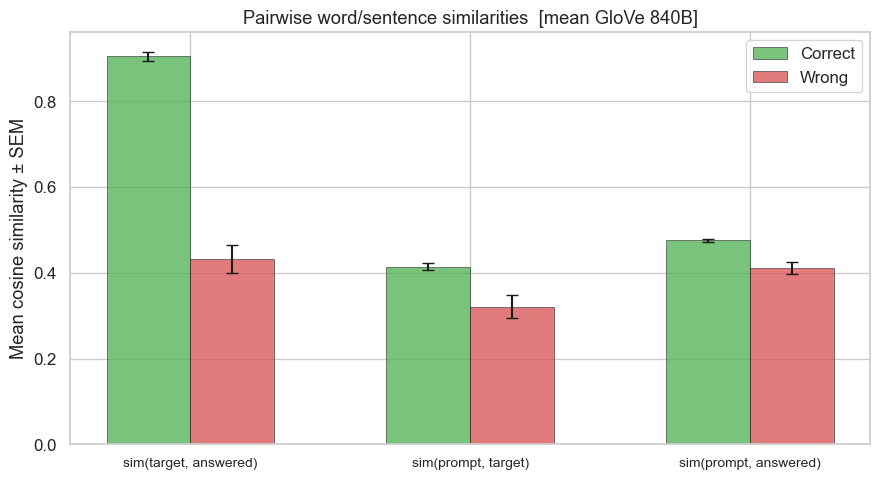

In [84]:
# ── Grouped bar: mean similarity correct vs wrong ─────────────────────────
# (meaningful only in GloVe mode where all three are in the same space)
cols_plot = ['sim_target_answered', 'sim_prompt_target', 'sim_prompt_answered']
labels_plot = ['sim(target, answered)', 'sim(prompt, target)', 'sim(prompt, answered)']

if not USE_SBERT:
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(cols_plot))
    width = 0.3

    for j, (grp_label, mask, color) in enumerate([
        ('Correct', beh_v['correct_loose'],   '#4caf50'),
        ('Wrong',  ~beh_v['correct_loose'],   '#d94f4f'),
    ]):
        sub = beh_v[mask]
        means = [sub[c].mean() for c in cols_plot]
        sems  = [sub[c].sem()  for c in cols_plot]
        offset = (j - 0.5) * width
        ax.bar(x + offset, means, width, yerr=sems,
               label=grp_label, color=color, alpha=0.75,
               capsize=4, edgecolor='k', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, fontsize=10)
    ax.set_ylabel('Mean cosine similarity ± SEM')
    ax.set_title(f'Pairwise word/sentence similarities  [{EMB_MODE}]')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('SBERT is in a different space from GloVe — cross-space similarity bar skipped.')
    print('Showing only sim(target, answered) in GloVe space below.')

    fig, ax = plt.subplots(figsize=(5, 4))
    for j, (grp_label, mask, color) in enumerate([
        ('Correct', beh_v['correct_verbatim'],  '#4caf50'),
        ('Wrong',  ~beh_v['correct_verbatim'],  '#d94f4f'),
    ]):
        sub = beh_v[mask]
        m, s = sub['sim_target_answered'].mean(), sub['sim_target_answered'].sem()
        ax.bar(j, m, yerr=s, color=color, alpha=0.75,
               capsize=5, edgecolor='k', linewidth=0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Correct', 'Wrong'])
    ax.set_ylabel('GloVe cosine similarity ± SEM')
    ax.set_title('sim(target, answered)  by correctness')
    plt.tight_layout()
    plt.show()

In [85]:
# ── PCA of PROMPT SENTENCE embeddings ────────────────────────────────────
# Build matrix: unique (patient, target, prompt_sentence)
uniq = (
    beh_v.drop_duplicates(subset=['patient', 'target', 'prompt_sentence'])
    .reset_index(drop=True)
)
vecs, keep = [], []
for _, row in uniq.iterrows():
    v = sent_cache.get(row.prompt_sentence)
    if v is not None:
        vecs.append(v)
        keep.append(True)
    else:
        keep.append(False)

uniq    = uniq[keep].reset_index(drop=True)
sent_mat = np.vstack(vecs).astype(np.float64)
print(f'Sentence embedding matrix: {sent_mat.shape}')

pca      = PCA(n_components=2, random_state=42)
sent_2d  = pca.fit_transform(sent_mat)
var_expl = pca.explained_variance_ratio_ * 100
print(f'PCA explained variance: {var_expl.sum():.1f}%  (PC1={var_expl[0]:.1f}%, PC2={var_expl[1]:.1f}%)')

Sentence embedding matrix: (341, 300)
PCA explained variance: 22.6%  (PC1=12.8%, PC2=9.8%)


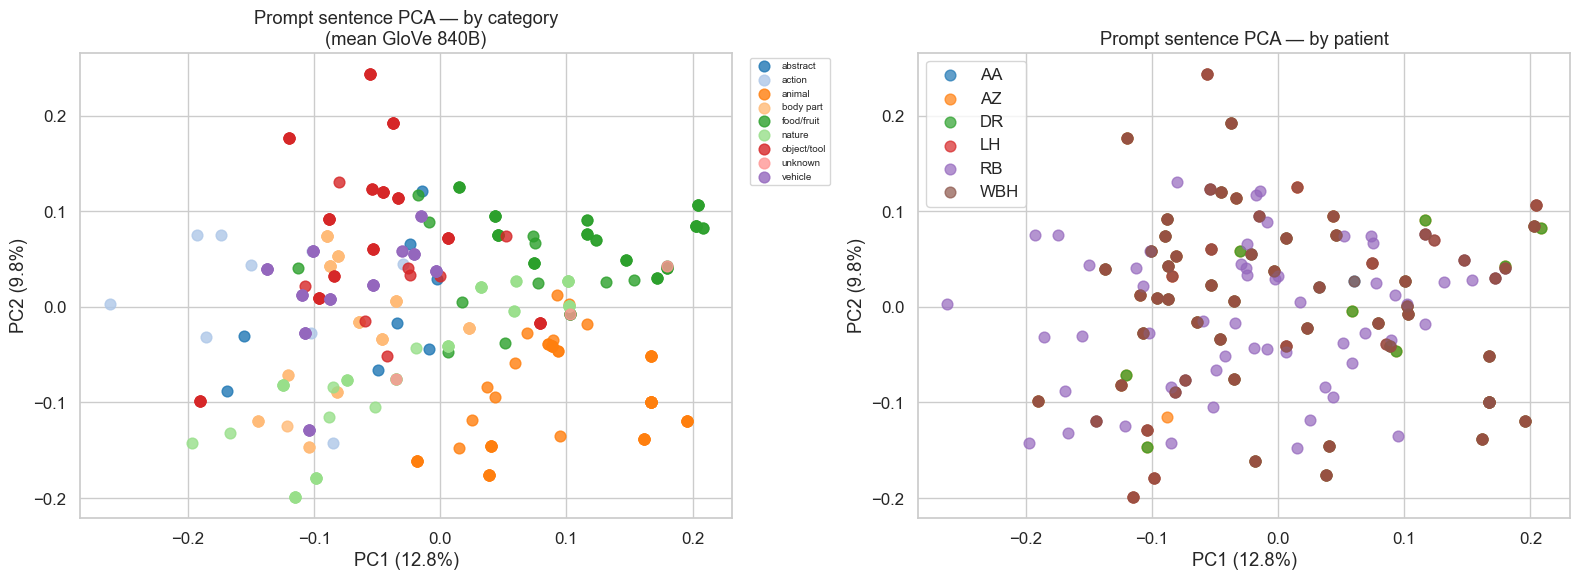

In [86]:
cats_arr  = uniq['category'].fillna('unknown').values
pts_arr   = uniq['patient'].values
uniq_cats = sorted(set(cats_arr))
cat_pal   = dict(zip(uniq_cats, sns.color_palette('tab20', len(uniq_cats))))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colour by category
ax = axes[0]
for cat in uniq_cats:
    m = cats_arr == cat
    ax.scatter(sent_2d[m, 0], sent_2d[m, 1],
               color=cat_pal[cat], label=cat, alpha=0.8, s=60)
ax.set_xlabel(f'PC1 ({var_expl[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_expl[1]:.1f}%)')
ax.set_title(f'Prompt sentence PCA — by category\n({EMB_MODE})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

# Right: colour by patient
ax = axes[1]
for pt in PATIENTS:
    m = pts_arr == pt
    if not m.any():
        continue
    ax.scatter(sent_2d[m, 0], sent_2d[m, 1],
               color=PAL[pt], label=pt, alpha=0.7, s=60)
ax.set_xlabel(f'PC1 ({var_expl[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_expl[1]:.1f}%)')
ax.set_title(f'Prompt sentence PCA — by patient')
ax.legend()

plt.tight_layout()
plt.show()

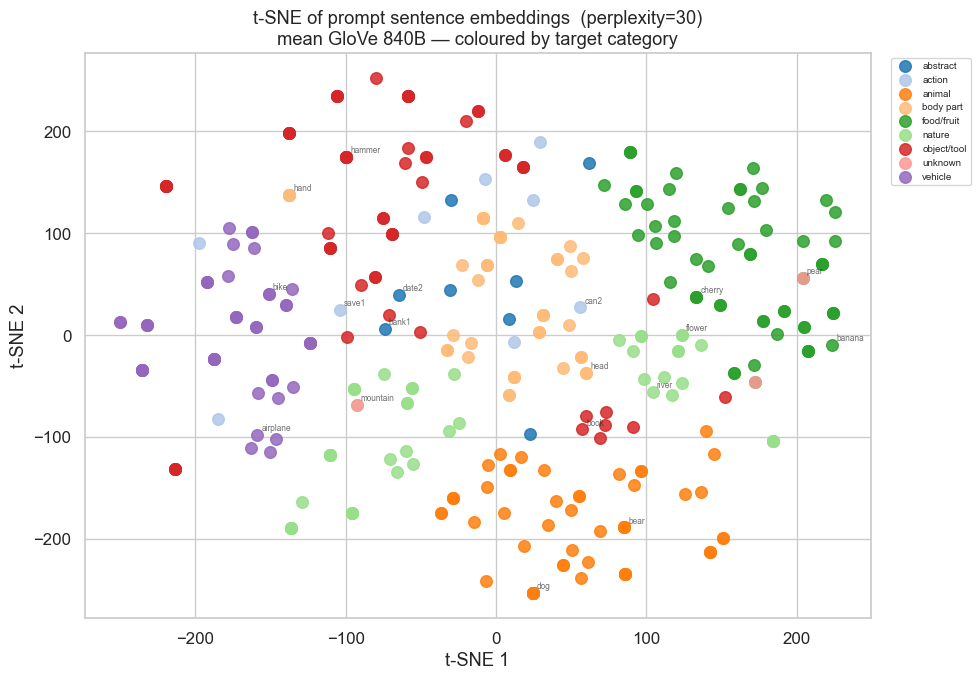

In [87]:
# ── t-SNE ─────────────────────────────────────────────────────────────────
if len(sent_mat) > 10:
    perp = min(30, max(5, len(sent_mat) // 4))
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                n_iter=1000, init='pca')
    sent_tsne = tsne.fit_transform(sent_mat)

    fig, ax = plt.subplots(figsize=(10, 7))
    for cat in uniq_cats:
        m = cats_arr == cat
        ax.scatter(sent_tsne[m, 0], sent_tsne[m, 1],
                   color=cat_pal[cat], label=cat, alpha=0.85, s=70)
        # Annotate first 2 items of each category
        for idx in np.where(m)[0][:2]:
            ax.annotate(
                uniq.iloc[idx]['target'],
                (sent_tsne[idx, 0], sent_tsne[idx, 1]),
                fontsize=6, alpha=0.65,
                xytext=(3, 3), textcoords='offset points',
            )
    ax.set_title(
        f't-SNE of prompt sentence embeddings  (perplexity={perp})\n'
        f'{EMB_MODE} — coloured by target category'
    )
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough unique sentences for t-SNE.')

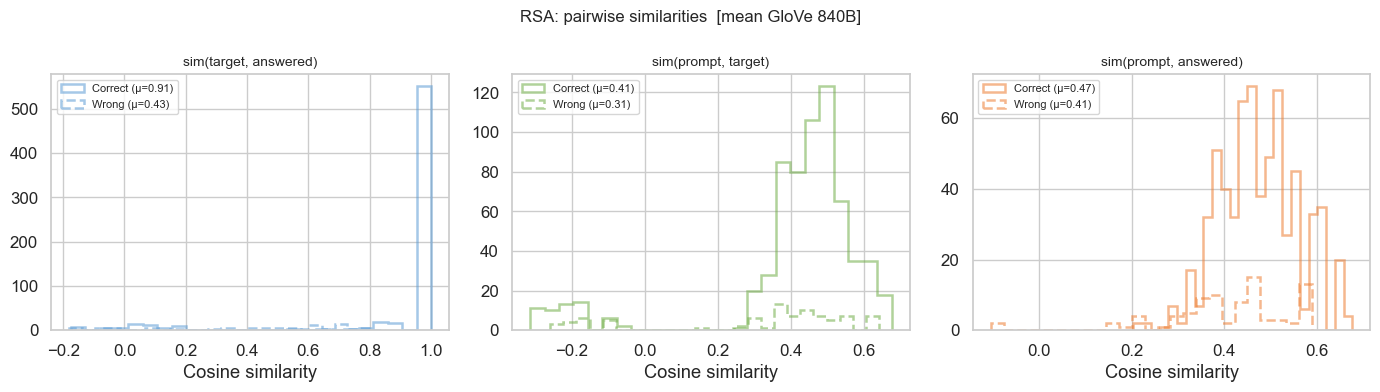

Mean similarities  (correct vs wrong):
         sim_TA  sim_PT  sim_PA
correct                        
Wrong     0.432   0.312   0.407
Correct   0.905   0.412   0.473


In [88]:
# ── RSA (mean-GloVe only — all three in same space) ───────────────────────
if not USE_SBERT:
    rsa_records = []
    for _, row in beh_v.iterrows():
        vt = glove_cache.get(row.target)
        va = glove_cache.get(row.answered) if row.valid_response else None
        vs = sent_cache.get(row.prompt_sentence)
        if vt is None or va is None or vs is None:
            continue
        rsa_records.append(dict(
            target   = row.target,
            answered = row.answered,
            category = row.category,
            correct  = row.correct_loose,
            sim_TA   = safe_cosine(vt, va),   # target ↔ answered
            sim_PT   = safe_cosine(vs, vt),   # prompt ↔ target
            sim_PA   = safe_cosine(vs, va),   # prompt ↔ answered
        ))

    if rsa_records:
        rsa = pd.DataFrame(rsa_records)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        for ax, col, title, color in zip(
            axes,
            ['sim_TA', 'sim_PT', 'sim_PA'],
            ['sim(target, answered)', 'sim(prompt, target)', 'sim(prompt, answered)'],
            ['#5b9bd5', '#70ad47', '#ed7d31'],
        ):
            for lbl, ls, mask in [
                ('Correct', '-',  rsa['correct']),
                ('Wrong',  '--', ~rsa['correct']),
            ]:
                sub = rsa.loc[mask, col].dropna()
                ax.hist(sub, bins=25, alpha=0.55, histtype='step',
                        linestyle=ls, color=color, linewidth=1.8,
                        label=f'{lbl} (μ={sub.mean():.2f})')
            ax.set_title(title, fontsize=10)
            ax.set_xlabel('Cosine similarity')
            ax.legend(fontsize=8)

        fig.suptitle(f'RSA: pairwise similarities  [{EMB_MODE}]', fontsize=12)
        plt.tight_layout()
        plt.show()

        print('Mean similarities  (correct vs wrong):')
        print(
            rsa.groupby('correct')[['sim_TA','sim_PT','sim_PA']]
            .mean().round(3)
            .rename(index={True: 'Correct', False: 'Wrong'})
            .to_string()
        )
    else:
        print('No trials with all three embeddings available for RSA.')
else:
    print('RSA in GloVe space skipped because SBERT was used for sentence embeddings.')
    print('Set USE_SBERT=False in the SBERT cell to run RSA in mean-GloVe mode.')

---
## Summary

| Finding | Variable |
|---------|----------|
| Overall accuracy per patient | `summary` DataFrame |
| Per-word accuracy heatmap | `pivot_pct` (words × patients) |
| Hardest/easiest words | `hardest`, `easiest` |
| Category accuracy | `cat_pivot` |
| Close misses (wrong + sim ≥ 0.5) | `close_misses` DataFrame |
| Per-trial GloVe similarity | `beh_v['glove_sim']` |
| Reaction time summary | `rt_summary` DataFrame |
| All behavioral data | `beh` (all trials), `beh_v` (valid answers only) |
| Sentence embeddings | `sent_mat`, `sent_2d` (PCA), `sent_tsne` |
| RSA similarity table | `rsa` DataFrame (GloVe mode only) |